In [1]:
import os
import pandas as pd
import numpy as np
import scipy

import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

import tensorflow as tf

from sklearn.svm import SVC, LinearSVC
from sklearn.neural_network import MLPRegressor, MLPClassifier
from sklearn.linear_model import (
                LogisticRegression, LogisticRegressionCV, LinearRegression,
                RidgeCV, LassoCV, ElasticNetCV, BayesianRidge
)

from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler
from sklearn.metrics import roc_auc_score, r2_score, PredictionErrorDisplay

from tqdm.notebook import tqdm
from time import time

import warnings
warnings.simplefilter('ignore')
warnings.filterwarnings('ignore')

## -- Set Global Seed --
class CFG():
    FOLDS  = 5
    SEED   = 42
    GREEN  = '\033[32m'
    YELLOW = '\033[33m'
    RESET  = '\033[0m'

# pd.options.mode.copy_on_write = True
pd.set_option('display.max_columns', 1000)
sns.set_style("whitegrid")
# plt.style.use('ggplot')

# plt.rcParams['axes.prop_cycle'] = cycler(color=['red', 'green', 'blue'])
plt.rcParams.update({
    # "figure.facecolor": '#0f0f1a', # Outer panel (figure)
    # "axes.facecolor":   '#1a1a2e', # Inner panel (image)
    # "axes.edgecolor":   '#444466',
    # "axes.labelcolor":  '#e0e0ff',
    # "text.color":       'lightblue',
    # "xtick.color":      '#e0e0ff',
    # "ytick.color":      '#e0e0ff',
    # "grid.color":       '#2a2a4a',
    "grid.alpha":       0.5,
    "font.family":      'monospace',
})

PALETTE = ['c', 'r', 'darkorange', '#3A86FF', 'y']
sns.set_palette(PALETTE)
cmap = sns.diverging_palette(0, 230, 90, 60, as_cmap=True)

print(f"CLASSIC {CFG.GREEN} GREEN {CFG.RESET} {CFG.YELLOW} YELLOW {CFG.RESET}")

2026-05-31 21:06:47.662982: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1780261607.909548      16 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1780261607.981246      16 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1780261608.552272      16 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780261608.552340      16 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780261608.552344      16 computation_placer.cc:177] computation placer alr

CLASSIC  GREEN   YELLOW 


# 1.__LOAD DATA

In [2]:
## -- ⚠️ IMPORTANT: SELECT PLATFORM ⚠️ --
PLATFORM = 'kaggle' # -> 'colab' 'kaggle'

if PLATFORM == 'kaggle':
    PATH = '/kaggle/input/competitions/playground-series-s6e5/'
    submit = pd.read_csv(PATH+'sample_submission.csv')
    train = pd.read_csv(PATH+"train.csv").drop(columns=['id'])
elif PLATFORM == 'colab':
    from google.colab import drive
    drive.mount('/content/drive')

    PATH = '/content/drive/MyDrive/-- shared_notebooks --/Ps6e5 | F1 Pits Stop/_f1_data/'
    submit = pd.read_csv(PATH+'sample_submission.csv')
    train = pd.read_csv(PATH+'train.csv').drop(columns=['id'])
## =================================================================================
TARGET = train.columns[-1]
y_true = train[TARGET].astype(int)

print(f"✓ Dataset ready!")

✓ Dataset ready!


In [3]:
# ## -- Append predicted columns as extra features --
# ## -- os.walk: Deep search with subfolders --
# def dataloader(filepath, train_prefix, test_prefix):
#     train_df = pd.DataFrame()
#     test_df  = pd.DataFrame()

#     desc = 'Loading .npy files'
#     for (root, dirs, files) in os.walk(filepath):
#         for i, file in tqdm(enumerate(sorted(files), 1), total=len(files), desc=desc):
#             # if i%10 == 0: print(f'{i}%.. ', end='')
#             if file.endswith('.npy') and train_prefix in file:
#                 train_path = np.load(os.path.join(root, file))
#                 train_df = pd.concat([train_df, pd.Series(train_path, name=file[4:-4])], axis=1)
#             elif file.endswith('.npy') and test_prefix in file:
#                 test_path = np.load(os.path.join(root, file))
#                 test_df = pd.concat([test_df, pd.Series(test_path, name=file[5:-4])], axis=1)

#     desc = 'Loading .parquet files'
#     for (root, dirs, files) in os.walk(filepath):
#         for i, file in tqdm(enumerate(sorted(files), 1), total=len(files), desc=desc):
#             # if i%10 == 0: print(f"{i}%.. ", end="")
#             if file.endswith('.parquet') and train_prefix in file:
#                 train_path = os.path.join(root, file)
#                 train_df = pd.concat([train_df, pd.read_parquet(train_path)], axis=1)
#             elif file.endswith('.parquet') and test_prefix in file:
#                 test_path = os.path.join(root, file)
#                 test_df = pd.concat([test_df, pd.read_parquet(test_path)], axis=1)
#     print()
#     print(f"OOF  Shape: {train_df.shape}")
#     print(f"TEST Shape: {test_df.shape}")
#     print()

#     return train_df, test_df

In [4]:
# def rename_duplicate_cols(df: pd.DataFrame) -> pd.DataFrame:
#     original_cols = list(df.columns)
#     new_cols = []
#     # Track how many times we've seen each original name
#     seen = {}

#     for col in tqdm(original_cols, desc="Fixing columns"):
#         if col not in seen:
#             # First occurrence: keep name unchanged
#             seen[col] = 1
#             new_cols.append(col)
#         else:
#             # Duplicate: append suffix _k where k starts at 0
#             suffix = seen[col] - 1 # 0 for first duplicate, 1 for second,
#             new_name = f"{col}_{suffix}"
#             new_cols.append(new_name)
#             seen[col] += 1

#     # Apply new column names
#     df_renamed = df.copy()
#     df_renamed.columns = new_cols

#     return df_renamed


In [5]:
# PATHS = [
#     '/kaggle/input/datasets/',
# ]

# ## -- Load dataframes --
# oofs = []
# preds  = []

# ## -- Load train/test datasets --
# for p in PATHS:
#     tr, ts = dataloader(p, 'oof', 'test')
#     oofs.append(tr)
#     preds.append(ts)

# ## -- Concat datasets --
# oof_df  = pd.concat(oofs, axis=1)
# pred_df = pd.concat(preds, axis=1)

# ## -- Drop models if necessary --
# for c in oof_df.columns:
#     if 'hillclimb' in c or 'stack' in c: #
#         oof_df.drop([c], axis=1, inplace=True)
#         pred_df.drop([c], axis=1, inplace=True)
#     elif c == TARGET:
#         oof_df.drop([c], axis=1, inplace=True)

# print('-'*50)
# ## -- Check for missingness --
# print(f'OOF  Null: {oof_df.isna().sum().sum()} | ',end='')
# print(f'TEST Null: {pred_df.isna().sum().sum()}')
# print('-'*50)

# ## -- Apply column rename function --
# oof_df = rename_duplicate_cols(oof_df)
# pred_df = rename_duplicate_cols(pred_df)

# print()
# print(f'{CFG.YELLOW}••••• Updated columns: {oof_df.shape[1]}')

# display(oof_df.head(3))
# print()
# display(pred_df.head(3))

In [6]:
## -- Append predicted columns as extra features --
## -- os.walk: Deep search with subfolders --
def dataloader(filepath, train_prefix, test_prefix):
    load_npy_train = {}
    load_npy_test  = {}

    load_par_train = []
    load_par_test  = []

    desc = 'Loading .npy files'
    for (root, dirs, files) in os.walk(filepath):
        for i, file in tqdm(enumerate(sorted(files), 1), total=len(files), desc=desc):
            if file.endswith('.npy') and train_prefix in file:
                load_npy_train[file[4:-4]] = np.load(os.path.join(root, file))
            elif file.endswith('.npy') and test_prefix in file:
                load_npy_test[file[5:-4]] = np.load(os.path.join(root, file))

    # desc = 'Loading .parquet files'
    # for (root, dirs, files) in os.walk(filepath):
    #     for i, file in tqdm(enumerate(sorted(files), 1), total=len(files), desc=desc):
    #         if file.endswith('.parquet') and train_prefix in file:
    #             load_par_train.append(pd.read_parquet(os.path.join(root, file)))
    #         elif file.endswith('.parquet') and test_prefix in file:
    #             load_par_test.append(pd.read_parquet(os.path.join(root, file)))

    train_npy_df = pd.DataFrame(load_npy_train)
    test_npy_df  = pd.DataFrame(load_npy_test)

    # train_par_df = pd.concat(load_par_train)
    # test_par_df  = pd.concat(load_par_test)

    print()
    print(f"OOF  Shape: {train_npy_df.shape}")
    print(f"TEST Shape: {test_npy_df.shape}")
    print()

    return train_npy_df, test_npy_df

def rename_duplicate_cols(df: pd.DataFrame) -> pd.DataFrame:
    original_cols = list(df.columns)
    new_cols = []
    # Track how many times we've seen each original name
    seen = {}

    for col in tqdm(original_cols, desc="Fixing columns"):
        if col not in seen:
            # First occurrence: keep name unchanged
            seen[col] = 1
            new_cols.append(col)
        else:
            # Duplicate: append suffix _k where k starts at 0
            suffix = seen[col] - 1 # 0 for first duplicate, 1 for second,
            new_name = f"{col}_{suffix}"
            new_cols.append(new_name)
            seen[col] += 1

    # Apply new column names
    df_renamed = df.copy()
    df_renamed.columns = new_cols

    return df_renamed


print('Data loading function ready!')

Data loading function ready!


In [7]:
## -- Load oof --
if PLATFORM == 'colab':
    data_path = '/content/files'
elif PLATFORM == 'kaggle':
    data_path = '/kaggle/input/datasets/'

oof_df, pred_df = dataloader(data_path, 'oof', 'test')

## -- Apply column rename function --
oof_df  = rename_duplicate_cols(oof_df)
pred_df = rename_duplicate_cols(pred_df)

print(f"All oof and test columns match? {all(oof_df.columns == pred_df.columns)}")

display(oof_df[:3])
display(pred_df[:3])

Loading .npy files: 0it [00:00, ?it/s]

Loading .npy files: 0it [00:00, ?it/s]

Loading .npy files:   0%|          | 0/32 [00:00<?, ?it/s]

Loading .npy files:   0%|          | 0/12 [00:00<?, ?it/s]

Loading .npy files:   0%|          | 0/210 [00:00<?, ?it/s]

...

Fixing columns:   0%|          | 0/149 [00:00<?, ?it/s]

Fixing columns:   0%|          | 0/149 [00:00<?, ?it/s]

All oof and test columns match? True


,knn_dis_None_91968,knn_dis_first_91953,knn_orig_dis_None_91732,knn_orig_dis_first_91719,knn_orig_uni_None_91679,knn_orig_uni_first_91661,knn_uni_None_91899,knn_uni_first_91883,log_None_92228,log_first_92227,log_orig_None_92213,log_orig_first_92211,mlp_None_94236,mlp_first_94196,mlp_orig_None_94129,mlp_orig_first_94161,h2o_base2_hillclimb_95097,h2o_base_hillclimb_95174,h2o_cv0base_hillclimb_95122,h2o_cv1base_hillclimb_9486,h2o_orig__hillclimb_95288,h2o_orig__hillclimb_95304,bartz_orig_p_93989,bartz_orig_w_94158,bartz_v0_p_93989,bartz_v0_w_94036,cat_orig_bayes__95251,cat_orig_bern__95268,cat_orig_loss__95297,cat_orig_ord_bayes__95183,cat_v0_bayes__95218,cat_v0_bern_42_95161,cat_v0_loss_42_95206,cat_v0_ord_bayes_42_9517,hist_orig_False_95179,hist_orig_True_95277,kerasFS_orig_93907,kerasFS_v0_94474,kerasFS_v2_9447,kerasFS_v3_94319,kerasFS_v3_94448,kerasFSadam_fe0_94593,kerasFSrms_fe0_94455,lgb_fe0_bag_0_95202,lgb_fe0_bag_777_95075,lgb_fe0_goss_0_95201,lgb_fe0_goss_777_95078,lgb_orig_bag__95316,lgb_orig_goss__95316,lgb_v0_bag_42_95268,lgb_v0_goss_42_95266,lgb_v1_bag_1234_9523,lgb_v1_goss_1234_9523,log_orig_False_93187,log_orig_True_93212,log_v0_None_932,log_v0_first_93144,log_v1_None_93384,log_v1_first_93346,mlp_plr_94815,mlp_plr_is2023_94757,mlp_rtd_94856,mlp_rtd_is2023_94832,nn_cat_95105,nn_cat_95156,nn_xgb_95285,pseudo_xgb-loss_tabm_95351,pseudo_xgb_tabm_95274,pseudo_xgb_tabm_95343,pytab_v0_mlpPLR_942739,pytab_v0_mlpRTDL_942743,pytab_v0_resRTDL_9419,realmlp_95401,realmlp_is2023_95403,resnet_94814,resnet_rtd_is2023_94772,rfc_orig_ent_95045,rfc_orig_gini_95005,rfc_v0_ent_94733,rfc_v0_entropy_94902,rfc_v0_gini_94661,rfc_v0_gini_94862,scikeras_orig_94244,scikeras_v0_94123,tabm_95242,tabm_is2023_95207,tabnet_mlpFE_94588,tabnet_mlpFE_94681,tabnet_v0_embed_origFalse_94142,tabnet_v0_embed_origTrue_9394,tabnet_v0_tabvec_orig_False_93891,tabnet_v0_tabvec_orig_True_9405,tabpfn_mlpFE_94253,tabpfn_mlp_94281,tanpfn__94414,tanpfn__94786,tanpfn_orig__94269,xgb_fe0_gbt42_9521,xgb_fe0_grad42_95175,xgb_fe0_loss42_95215,xgb_orig_gbt_95385,xgb_orig_grad42_95353,xgb_orig_loss_95398,xgb_v0_gbt0_95292,xgb_v0_grad0_95255,xgb_v0_grad0_95258,xgb_v0_loss0_95294,xlearn_v0_ffm_94469,xlearn_v0_fm_92667,xlearn_v0_linear_92214,xlearn_v1_ffm_94672,xlearn_v1_fm_92865,xlearn_v1_lin_92392,xlearn_v2_fm_93023,xtra_orig_False_94716,xtra_orig_True_94829,ydf_v0_global_cart_94958,ydf_v0_global_random_94939,ydf_v0_global_random_94991,ydf_v0_local_cart_94944,ydf_v0_local_cart_9498,ydf_v0_local_random_94924,ydfcats_orig_global_random_95055,ydfcats_orig_local_cart_95042,ydfcats_orig_local_random_95031,ydfnums_orig_global_random_95127,ydfnums_orig_local_random_9511,lgb_fe0_bag_0_95071,lgb_fe0_bag_777_95199,lgb_fe0_goss_0_95074,lgb_fe0_goss_777_95201,lgb_v0_bag_0_95269,lgb_v0_bag_1234_95273,lgb_v0_bag_24611_95272,lgb_v0_bag_42_9512,lgb_v0_bag_777_95266,lgb_v0_goss_0_95268,lgb_v0_goss_1234_95272,lgb_v0_goss_24611_95267,lgb_v0_goss_42_95121,lgb_v0_goss_777_95268,lgb_v1_bag_42_94992,lgb_v1_goss_42_95048,lgb_v2_bag_24611_94745,lgb_v2_bag_42_95021,lgb_v2_goss_24611_94967,lgb_v2_goss_42_95019,lgb_v3_bag_42_95118,lgb_v3_goss_42_95122
0,0.765424,0.796491,0.783483,0.706912,0.797551,0.698075,0.775439,0.783872,0.754788,0.755806,0.752221,0.753896,0.780890,0.821779,0.848892,0.610443,0.746097,0.733708,0.641434,0.711514,0.763841,0.663612,0.893425,0.795485,0.711223,0.759928,0.799852,0.722135,0.817154,0.776478,0.748791,0.634650,0.766097,0.753024,0.717942,0.729341,0.766321,0.847226,0.943925,0.868942,0.839812,0.910576,0.809962,0.731654,0.824209,0.719390,0.824336,0.798179,0.824304,0.788603,0.778593,0.728951,0.753092,0.814285,0.812273,0.802627,0.760452,0.764082,0.752858,0.800426,0.807186,0.796907,0.747499,0.731878,0.670840,0.635453,0.788564,0.764020,0.784016,0.751398,0.866121,0.898937,0.751083,0.720677,0.751249,0.761728,0.753000,0.755135,0.789323,0.734451,0.795209,0.757956,0.749654,0.652773,0.792089,0.803740,0.598817,0.733578,0.850666,0.613592,0.617842,0.673802,0.779895,0.795915,0.859939,0.820573

,knn_dis_None_91968,knn_dis_first_91953,knn_orig_dis_None_91732,knn_orig_dis_first_91719,knn_orig_uni_None_91679,knn_orig_uni_first_91661,knn_uni_None_91899,knn_uni_first_91883,log_None_92228,log_first_92227,log_orig_None_92213,log_orig_first_92211,mlp_None_94236,mlp_first_94196,mlp_orig_None_94129,mlp_orig_first_94161,h2o_base2_hillclimb_95097,h2o_base_hillclimb_95174,h2o_cv0base_hillclimb_95122,h2o_cv1base_hillclimb_9486,h2o_orig__hillclimb_95288,h2o_orig__hillclimb_95304,bartz_orig_p_93989,bartz_orig_w_94158,bartz_v0_p_93989,bartz_v0_w_94036,cat_orig_bayes__95251,cat_orig_bern__95268,cat_orig_loss__95297,cat_orig_ord_bayes__95183,cat_v0_bayes__95218,cat_v0_bern_42_95161,cat_v0_loss_42_95206,cat_v0_ord_bayes_42_9517,hist_orig_False_95179,hist_orig_True_95277,kerasFS_orig_93907,kerasFS_v0_94474,kerasFS_v2_9447,kerasFS_v3_94319,kerasFS_v3_94448,kerasFSadam_fe0_94593,kerasFSrms_fe0_94455,lgb_fe0_bag_0_95202,lgb_fe0_bag_777_95075,lgb_fe0_goss_0_95201,lgb_fe0_goss_777_95078,lgb_orig_bag__95316,lgb_orig_goss__95316,lgb_v0_bag_42_95268,lgb_v0_goss_42_95266,lgb_v1_bag_1234_9523,lgb_v1_goss_1234_9523,log_orig_False_93187,log_orig_True_93212,log_v0_None_932,log_v0_first_93144,log_v1_None_93384,log_v1_first_93346,mlp_plr_94815,mlp_plr_is2023_94757,mlp_rtd_94856,mlp_rtd_is2023_94832,nn_cat_95105,nn_cat_95156,nn_xgb_95285,pseudo_xgb-loss_tabm_95351,pseudo_xgb_tabm_95274,pseudo_xgb_tabm_95343,pytab_v0_mlpPLR_942739,pytab_v0_mlpRTDL_942743,pytab_v0_resRTDL_9419,realmlp_95401,realmlp_is2023_95403,resnet_94814,resnet_rtd_is2023_94772,rfc_orig_ent_95045,rfc_orig_gini_95005,rfc_v0_ent_94733,rfc_v0_entropy_94902,rfc_v0_gini_94661,rfc_v0_gini_94862,scikeras_orig_94244,scikeras_v0_94123,tabm_95242,tabm_is2023_95207,tabnet_mlpFE_94588,tabnet_mlpFE_94681,tabnet_v0_embed_origFalse_94142,tabnet_v0_embed_origTrue_9394,tabnet_v0_tabvec_orig_False_93891,tabnet_v0_tabvec_orig_True_9405,tabpfn_mlpFE_94253,tabpfn_mlp_94281,tanpfn__94414,tanpfn__94786,tanpfn_orig__94269,xgb_fe0_gbt42_9521,xgb_fe0_grad42_95175,xgb_fe0_loss42_95215,xgb_orig_gbt_95385,xgb_orig_grad42_95353,xgb_orig_loss_95398,xgb_v0_gbt0_95292,xgb_v0_grad0_95255,xgb_v0_grad0_95258,xgb_v0_loss0_95294,xlearn_v0_ffm_94469,xlearn_v0_fm_92667,xlearn_v0_linear_92214,xlearn_v1_ffm_94672,xlearn_v1_fm_92865,xlearn_v1_lin_92392,xlearn_v2_fm_93023,xtra_orig_False_94716,xtra_orig_True_94829,ydf_v0_global_cart_94958,ydf_v0_global_random_94939,ydf_v0_global_random_94991,ydf_v0_local_cart_94944,ydf_v0_local_cart_9498,ydf_v0_local_random_94924,ydfcats_orig_global_random_95055,ydfcats_orig_local_cart_95042,ydfcats_orig_local_random_95031,ydfnums_orig_global_random_95127,ydfnums_orig_local_random_9511,lgb_fe0_bag_0_95071,lgb_fe0_bag_777_95199,lgb_fe0_goss_0_95074,lgb_fe0_goss_777_95201,lgb_v0_bag_0_95269,lgb_v0_bag_1234_95273,lgb_v0_bag_24611_95272,lgb_v0_bag_42_9512,lgb_v0_bag_777_95266,lgb_v0_goss_0_95268,lgb_v0_goss_1234_95272,lgb_v0_goss_24611_95267,lgb_v0_goss_42_95121,lgb_v0_goss_777_95268,lgb_v1_bag_42_94992,lgb_v1_goss_42_95048,lgb_v2_bag_24611_94745,lgb_v2_bag_42_95021,lgb_v2_goss_24611_94967,lgb_v2_goss_42_95019,lgb_v3_bag_42_95118,lgb_v3_goss_42_95122
0,0.016856,0.016879,0.01693,0.016786,0.017021,0.016880,0.016866,0.01689,0.007787,0.008064,0.008907,0.009557,0.006324,0.004464,0.003492,0.007503,0.000800,0.000812,0.000767,0.000744,0.001038,0.000890,0.009864,0.011334,0.009104,0.007144,0.005393,0.004256,0.003438,0.005323,0.005934,0.003606,0.004711,0.005000,0.004356,0.003085,0.000104,0.005386,0.004766,0.003119,0.004816,0.002254,0.003119,0.004800,0.004289,0.004965,0.004268,0.004757,0.004539,0.004582,0.004627,0.005288,0.005344,0.002664,0.003621,0.002821,0.002805,0.002020,0.002062,0.002775,0.004914,0.003042,0.004843,0.003316,0.004405,0.003920,0.004422,0.004385,0.005503,0.006386,0.002263,0.002292,0.003550,0.003211,0.001592,0.002871,0.002797,0.003032,0.004043,0.004990,0.003954,0.003026,0.006626,0.002875,0.004006,0.002737,0.004760,0.003130,0.003631,0.003611,0.004998,0.006785,0.007138,0.001671,0.001782,0.001611,0

In [8]:
## -- Confirm feature names consistency --
for i, enum in enumerate([oof_df.columns == pred_df.columns]):
    print(i, enum)

0 [ True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True]


In [9]:
oof_df.isna().sum().sum(), pred_df.isna().sum().sum()

(np.int64(0), np.int64(0))

In [10]:
print(f"""
-> OOFS shape: {oof_df.shape}
-> TEST shape: {pred_df.shape}
-> y_true    : {y_true.shape}
    """)


-> OOFS shape: (439140, 149)
-> TEST shape: (188165, 149)
-> y_true    : (439140,)
    


In [11]:
## -- Check for values ouside 0-1 range --
for col in oof_df.columns:
    if any(oof_df[col] > 1.0) | any(oof_df[col] < 0.0):
        print('🔴', end='')
    else:
        print('🟢', end='')

🟢🟢🟢🟢🟢🟢🟢🟢🟢🟢🟢🟢🟢🟢🟢🟢🟢🟢🟢🟢🟢🟢🟢🟢🟢🟢🟢🟢🟢🟢🟢🟢🟢🟢🟢🟢🟢🟢🟢🟢🟢🟢🟢🟢🟢🟢🟢🟢🟢🟢🟢🟢🟢🟢🟢🟢🟢🟢🟢🟢🟢🟢🟢🟢🟢🟢🟢🟢🟢🟢🟢🟢🟢🟢🟢🟢🟢🟢🟢🟢🟢🟢🟢🟢🟢🟢🟢🟢🟢🟢🟢🟢🟢🟢🟢🟢🟢🟢🟢🟢🟢🟢🟢🟢🟢🟢🟢🟢🟢🟢🟢🟢🟢🟢🟢🟢🟢🟢🟢🟢🟢🟢🟢🟢🟢🟢🟢🟢🟢🟢🟢🟢🟢🟢🟢🟢🟢🟢🟢🟢🟢🟢🟢🟢🟢🟢🟢🟢🟢

In [12]:
from sklearn.inspection import permutation_importance

def plot_permutation_importance(model, X, y, scoring='neg_log_loss', categories=None):
    if categories is not None:
        for c in categories:
            X[c] = X[c].factorize()[0]
            X[c] = X[c].astype('category')

    X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, random_state=42)

    ## -- Compute Model Importances --
    print(f" ⚙️ Training base model... ", end='')
    model.fit(X_train, y_train)
    model_importances = pd.Series(model.coef_[0], index=X.columns).sort_values(ascending=False)
    print('Complete!')

    ## -- Compute Permutation Importances --
    print(f" ⚙️ Training permutation ({scoring})... ", end='')
    result = permutation_importance(
        model, X_test, y_test,
        n_repeats=10, #max_samples=0.9,
        scoring=scoring,
        random_state=42, n_jobs=-1
    )
    perm_sorted_idx = result.importances_mean.argsort()
    print('Complete!')

    fig, axs = plt.subplots(1, 2, figsize=(18, len(perm_sorted_idx)*0.25))

    sns.barplot(model_importances, orient='h', palette='RdYlBu_r', ax=axs[0])
    # model_importances.sort_values().plot.barh(ax=axs[0], palette='RdYlGn')
    axs[0].set_xlabel("Model importance")

    axs[1].boxplot(
        result.importances[perm_sorted_idx].T,
        tick_labels=X.columns[perm_sorted_idx], 
        orientation='horizontal',
        whis=(0, 100),
    )
    axs[1].axvline(x=0, color="k", linestyle="--")
    axs[1].set_xlabel("Permutaion importance")
    title_ = "Logistic (coefs) vs. Permutation (scores) on validation data"
    fig.suptitle(title_, fontsize=15, fontweight='semibold', y=1.0)
    _ = fig.tight_layout()

print('Permutation Importance function ready!')

Permutation Importance function ready!


 ⚙️ Training base model... Complete!
 ⚙️ Training permutation (roc_auc)... Complete!
CPU times: user 7.87 s, sys: 1.21 s, total: 9.08 s
Wall time: 1min 55s


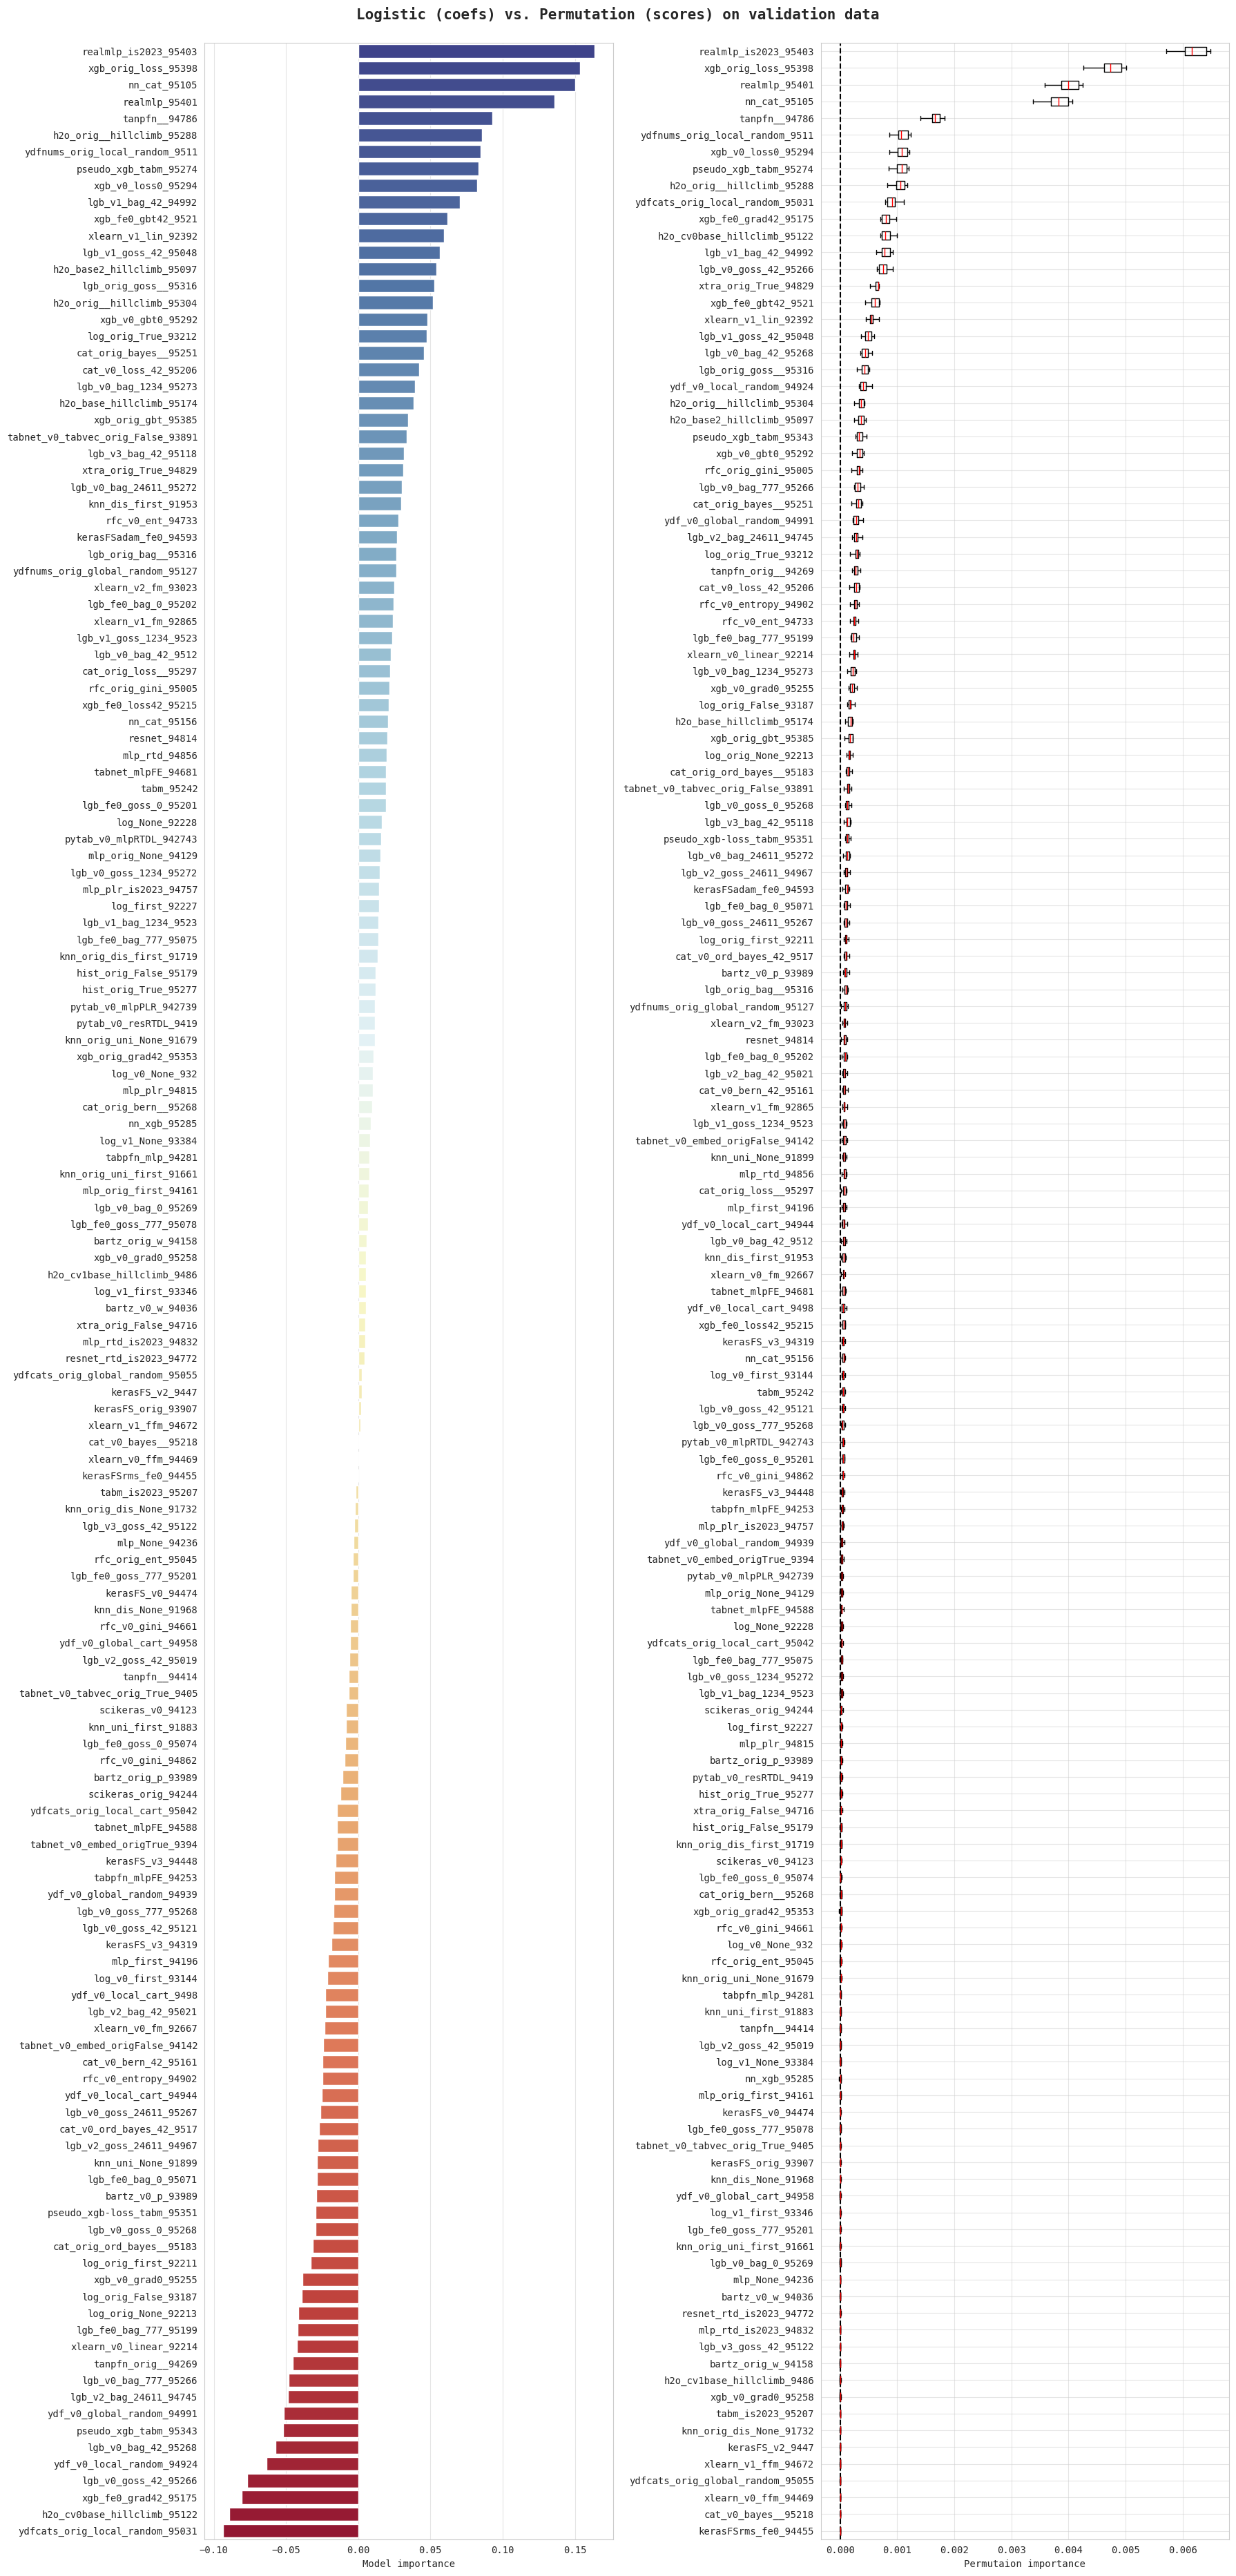

In [13]:
%%time

## -- Permutation plot --
scorer = 'roc_auc'
PARAMS = {
    'max_iter': 10_000,
    'cv': 5,
    'tol': 1e-4,
    'n_jobs': -1, 
    'scoring': scorer,
    'random_state': CFG.SEED,
}

lr_model = LogisticRegressionCV(**PARAMS)

oof_logits = oof_df.copy()

for col in oof_logits.columns:
    oof_logits.loc[:, col] = scipy.special.logit(np.clip(oof_logits[col].to_numpy(), 1e-10, 1-1e-10))

plot_permutation_importance(lr_model, oof_logits, y_true, scoring=scorer)

del oof_logits, lr_model

In [14]:
# try:
#     import skrub
# except:
#     %pip install -q skrub
#     import skrub

# try:
#     from venn_abers import VennAbersCalibrator
# except:
#     !pip install -q venn-abers
#     from venn_abers import VennAbersCalibrator

# try:
#     from cir_model import CenteredIsotonicRegression
# except:
#     !pip install -q cir-model
#     from cir_model import CenteredIsotonicRegression

In [15]:
## -- CIR/IR --
# try:
#     from cir_model import CenteredIsotonicRegression
# except:
#     %pip install -qq -U cir-model
#     from cir_model import CenteredIsotonicRegression

# from sklearn.isotonic import IsotonicRegression
# from cir_model import CenteredIsotonicRegression

# CIR_oof_df = pd.DataFrame()
# CIR_pred_df = pd.DataFrame()
# for c in oof_df.columns:
#     CIR = CenteredIsotonicRegression(out_of_bounds='clip').fit(oof_df[c], y_true)
#     CIR_oof_df[c]  = CIR.transform(oof_df[c])
#     CIR_pred_df[c] = CIR.transform(pred_df[c])

# IR_oof_df = pd.DataFrame()
# IR_pred_df = pd.DataFrame()
# for c in oof_df.columns:
#     IR = IsotonicRegression(out_of_bounds='clip').fit(oof_df[c], y_true)
#     IR_oof_df[c]  = IR.transform(oof_df[c])
#     IR_pred_df[c] = IR.transform(pred_df[c])

# CIR, IR

# fig, axs = plt.subplots(1, 3, figsize=(20, 5))
# sns.histplot(oof_df.iloc[:, 0], ax=axs[0]).set_title("Original")
# sns.histplot(IR_oof_df.iloc[:, 0], ax=axs[1]).set_title("Isotonic Regression")
# sns.histplot(CIR_oof_df.iloc[:, 0], ax=axs[2]).set_title("Centered Isotonic Regression")
# plt.show()

# pd.concat([oof_df.iloc[:, 0], IR_oof_df.iloc[:, 0], CIR_oof_df.iloc[:, 0]], axis=1).head()

## ENSEMBLE 1: STACKING

In [16]:
def train_meta(oof_df, pred_df, features, y_true, clf=None, scoring='roc_auc',
               kf_splits=5, n_cv=5, rank_first=False, logit_first=False, rank_logit=False, verbose=True):
    ## -- Stack with RidgeCV meta_model --
    kf = StratifiedKFold(n_splits=kf_splits, shuffle=True, random_state=CFG.SEED)

    oof_preds  = np.zeros(oof_df.shape[0])
    test_preds = np.zeros(pred_df.shape[0])

    val_scores = []
    oof_alphas = []
    
    if not isinstance(features, list):
        features = [features]

    if clf == 'mlp':
        print(f"===== MLP {kf_splits} folds | Total Models: {len(features)} =====")
    elif clf == 'bayes':
        print(f"===== Bayesian {kf_splits} folds | Total Models: {len(features)} =====")
    elif clf == 'elastic':
        print(f"===== Elastic {kf_splits} folds | Total Models: {len(features)} =====")
    elif clf == 'lasso':
        print(f"===== Lasso {kf_splits} folds | Total Models: {len(features)} =====")
    elif clf == 'log':
        print(f"===== Logistic {kf_splits} folds | Total Models: {len(features)} =====")
        if rank_first: print('Ranking data first...')
        if logit_first: print('Converting to logits first...')
    elif clf == 'keras':
        print(f"===== Keras {kf_splits} folds | Total Models: {len(features)} =====")
    elif clf == 'linreg':
        print(f"===== LinReg {kf_splits} folds | Total Models: {len(features)} =====")
    else:
        print(f"===== Ridge {kf_splits} folds | Total Models: {len(features)} =====")

    for fold, (trn_idx, val_idx) in enumerate(kf.split(oof_df, y_true)):

        X_trn, y_trn = oof_df.loc[trn_idx, features], y_true[trn_idx]
        X_val, y_val = oof_df.loc[val_idx, features], y_true[val_idx]
        X_test = pred_df[features].copy()

        if clf == 'mlp':
            model = MLPRegressor(max_iter=1000, hidden_layer_sizes=(150,), tol=1e-4)
            model.fit(X_trn, y_trn)
            oof_preds[val_idx] = model.predict(X_val)
            test_preds += model.predict(X_test)
            val_scores.append(roc_auc_score(y_val, oof_preds[val_idx]))
            if verbose:
                print(f"Fold {fold+1}/{kf.n_splits}: {val_scores[-1:][0]:.5f}")
        elif clf == 'bayes':
            model = BayesianRidge(max_iter=1000, tol=1e-4)
            if rank_first: 
                for col in features:
                    X_trn[col] = scipy.stats.rankdata(X_trn[col].to_numpy())
                    X_val[col] = scipy.stats.rankdata(X_val[col].to_numpy())
                    X_test[col] = scipy.stats.rankdata(X_test[col].to_numpy())

                    scaler = StandardScaler()
                    X_trn[col] = scaler.fit_transform(X_trn[[col]], y_true)
                    X_val[col] = scaler.transform(X_val[[col]])
                    X_test[col] = scaler.transform(X_test[[col]])

            model.fit(X_trn, y_trn)
            oof_preds[val_idx] = model.predict(X_val)
            test_preds += model.predict(X_test)
            val_scores.append(roc_auc_score(y_val, oof_preds[val_idx]))
            if verbose:
                print(f"Fold {fold+1}/{kf.n_splits}: {val_scores[-1:][0]:.5f}")
        elif clf == 'linreg':
            model = LinearRegression(n_jobs=os.cpu_count()) # tol=1e-5,
            model.fit(X_trn, y_trn)
            oof_preds[val_idx] = model.predict(X_val)
            test_preds += model.predict(X_test)
            val_scores.append(roc_auc_score(y_val, oof_preds[val_idx]))
            if verbose:
                print(f"Fold {fold+1}/{kf.n_splits}: {val_scores[-1:][0]:.5f}")
        elif clf == 'elastic':
            model = ElasticNetCV(max_iter=1000, alphas=20, cv=n_cv,tol=1e-4,
                                 n_jobs=os.cpu_count(),random_state=CFG.SEED)
            model.fit(X_trn, y_trn)
            oof_preds[val_idx] = model.predict(X_val)
            test_preds += model.predict(X_test)
            val_scores.append(roc_auc_score(y_val, oof_preds[val_idx]))
            if verbose:
                print(f"Fold {fold+1}/{kf.n_splits}: {val_scores[-1:][0]:.5f} | ", end='')
                print(f"Best Alpha: {model.alpha_:.4f}")
            oof_alphas.append(model.alpha_)
        elif clf == 'lasso':
            model = LassoCV(max_iter=1000, alphas=20, cv=n_cv,tol=1e-4,
                            n_jobs=os.cpu_count(),random_state=CFG.SEED,)
            model.fit(X_trn, y_trn)
            oof_preds[val_idx] = model.predict(X_val)
            test_preds += model.predict(X_test)
            val_scores.append(roc_auc_score(y_val, oof_preds[val_idx]))
            if verbose:
                print(f"Fold {fold+1}/{kf.n_splits}: {val_scores[-1:][0]:.5f} | ", end='')
                print(f"Best Alpha: {model.alpha_:.4f}")
            oof_alphas.append(model.alpha_)
        elif clf == 'log':
            model = LogisticRegressionCV(
                # Cs=np.linspace(0.01, 0.1, 10),
                max_iter=10_000,
                cv=n_cv,
                tol=1e-4,
                scoring=scoring,
                n_jobs=os.cpu_count(),
                random_state=CFG.SEED,
            )

            if rank_first:
                X_trn_rank  = X_trn.copy()
                X_val_rank  = X_val.copy()
                X_test_rank = X_test.copy()

                for col in features:
                    X_trn_rank[col]  = scipy.stats.rankdata(X_trn_rank[col].to_numpy())
                    X_val_rank[col]  = scipy.stats.rankdata(X_val_rank[col].to_numpy())
                    X_test_rank[col] = scipy.stats.rankdata(X_test_rank[col].to_numpy())

                    scaler = StandardScaler()
                    # scaler = skrub.SquashingScaler()
                    X_trn_rank[col]  = scaler.fit_transform(X_trn_rank[[col]], y_true)
                    X_val_rank[col]  = scaler.transform(X_val_rank[[col]])
                    X_test_rank[col] = scaler.transform(X_test_rank[[col]])

                model.fit(X_trn_rank, y_trn)

                oof_preds[val_idx] = model.predict_proba(X_val_rank)[:, 1] 
                test_preds += model.predict_proba(X_test_rank)[:, 1] 
                val_scores.append(roc_auc_score(y_val, oof_preds[val_idx]))
                if verbose:
                    print(f"Fold {fold+1}/{kf.n_splits}: {val_scores[-1:][0]:.5f} | ", end='')
                    print(f"Best 'C': {model.C_[0]:.4g}")
            elif logit_first:
                X_trn_logit  = X_trn.copy()
                X_val_logit  = X_val.copy()
                X_test_logit = X_test.copy()

                for col in features:
                    eps = 1e-10
                    X_trn_logit[col]  = scipy.special.logit(np.clip(X_trn_logit[col].to_numpy(), eps, 1-eps))
                    X_val_logit[col]  = scipy.special.logit(np.clip(X_val_logit[col].to_numpy(), eps, 1-eps))
                    X_test_logit[col] = scipy.special.logit(np.clip(X_test_logit[col].to_numpy(), eps, 1-eps))

                    scaler = StandardScaler()
                    # scaler = skrub.SquashingScaler()
                    X_trn_logit[col]  = scaler.fit_transform(X_trn_logit[[col]], y_true)
                    X_val_logit[col]  = scaler.transform(X_val_logit[[col]])
                    X_test_logit[col] = scaler.transform(X_test_logit[[col]])

                model.fit(X_trn_logit, y_trn)
                oof_preds[val_idx] = model.predict_proba(X_val_logit)[:, 1]
                test_preds += model.predict_proba(X_test_logit)[:, 1] 
                val_scores.append(roc_auc_score(y_val, oof_preds[val_idx]))
                if verbose:
                    print(f"Fold {fold+1}/{kf.n_splits}: {val_scores[-1:][0]:.5f} | ", end='')
                    print(f"Best 'C': {model.C_[0]:.4g}")
            elif rank_logit:
                print('Applying both rank and logits first...')
                X_trn_rank  = X_trn.copy()
                X_val_rank  = X_val.copy()
                X_test_rank = X_test.copy()

                for col in features:
                    X_trn_rank[col]  = scipy.stats.rankdata(X_trn_rank[col].to_numpy())
                    X_val_rank[col]  = scipy.stats.rankdata(X_val_rank[col].to_numpy())
                    X_test_rank[col] = scipy.stats.rankdata(X_test_rank[col].to_numpy())

                    scaler = StandardScaler()
                    X_trn_rank[col]  = scaler.fit_transform(X_trn_rank[[col]], y_true)
                    X_val_rank[col]  = scaler.transform(X_val_rank[[col]])
                    X_test_rank[col] = scaler.transform(X_test_rank[[col]])

                X_trn_logit  = X_trn.copy()
                X_val_logit  = X_val.copy()
                X_test_logit = X_test.copy()

                for col in features:
                    eps = 1e-10
                    X_trn_logit[col]  = scipy.special.logit(np.clip(X_trn_logit[col].to_numpy(), eps, 1-eps))
                    X_val_logit[col]  = scipy.special.logit(np.clip(X_val_logit[col].to_numpy(), eps, 1-eps))
                    X_test_logit[col] = scipy.special.logit(np.clip(X_test_logit[col].to_numpy(), eps, 1-eps))

                    scaler = StandardScaler()
                    X_trn_logit[col]  = scaler.fit_transform(X_trn_logit[[col]], y_true)
                    X_val_logit[col]  = scaler.transform(X_val_logit[[col]])
                    X_test_logit[col] = scaler.transform(X_test_logit[[col]])

                model.fit(pd.concat([X_trn_rank, X_trn_logit], axis=1), y_trn)
                oof_preds[val_idx] = model.predict_proba(pd.concat([X_val_rank, X_val_logit], axis=1))[:, 1]
                test_preds += model.predict_proba(pd.concat([X_test_rank, X_test_logit], axis=1))[:, 1]
                val_scores.append(roc_auc_score(y_val, oof_preds[val_idx]))
                if verbose:
                    print(f"Fold {fold+1}/{kf.n_splits}: {val_scores[-1:][0]:.5f} | ", end='')
                    print(f"Best 'C': {model.C_[0]:.4f}")
            else:
                model.fit(X_trn, y_trn)
                oof_preds[val_idx] = model.predict_proba(X_val)[:, 1]
                test_preds += model.predict_proba(X_test)[:, 1]
                val_scores.append(roc_auc_score(y_val, oof_preds[val_idx]))
                if verbose:
                    print(f"Fold {fold+1}/{kf.n_splits}: {val_scores[-1:][0]:.5f} | ", end='')
                    print(f"Best 'C': {model.C_[0]:.4f}")
        elif clf == 'keras':
            model = tf.keras.models.Sequential([
                # tf.keras.layers.BatchNormazation(),
                tf.keras.layers.Dense(1, activation='sigmoid', input_shape=(len(features),))
            ])
            optimizer = tf.keras.optimizers.Adam(learning_rate=0.01)
            model.compile(optimizer=optimizer, loss='binary_crossentropy', metrics=['auc'])

            X_trn_dt = tf.data.Dataset.from_tensor_slices((X_trn, y_trn))\
                                      .batch(64).prefetch(buffer_size=tf.data.AUTOTUNE)
            X_val_dt = tf.data.Dataset.from_tensor_slices(X_val).batch(64)
            X_test_dt = tf.data.Dataset.from_tensor_slices(X_test).batch(64)

            model.fit(X_trn_dt, epochs=10)
            oof_preds[val_idx] = model.predict(X_val_dt).ravel()
            test_preds += model.predict(X_test_dt).ravel()
            val_scores.append(roc_auc_score(y_val, oof_preds[val_idx]))
            if verbose:
                print(f" ℹ️ Fold {fold+1}/{kf.n_splits}: {val_scores[-1:][0]:.5f}\n")
        else:
            model = RidgeCV(
                alphas=(0.1, 1.0, 10.0, 100.0, 1000.0), scoring='neg_mean_squared_error', cv=n_cv)
            model.fit(X_trn, y_trn)
            oof_preds[val_idx] = model.predict(X_val)
            test_preds += model.predict(X_test)
            val_scores.append(roc_auc_score(y_val, oof_preds[val_idx]))
            if verbose:
                print(f"Fold {fold+1}/{kf.n_splits}: {val_scores[-1:][0]:.5f} | ", end='')
                print(f"Best Alpha: {model.alpha_}")

    test_preds /= kf.n_splits

    final_score = np.round(roc_auc_score(y_true, oof_preds), 5)
    print(f"\n{'-'*25}")
    print(f"✅ Stacking AUC: {final_score}")
    print('-'*25)

    return test_preds, oof_preds, final_score

print('Stack Model function ready!')

Stack Model function ready!


In [17]:
# kfcal = StratifiedKFold(n_splits=CFG.FOLDS, shuffle=True, random_state=CFG.SEED)

# oof_calib  = np.zeros(oof_df.shape[0])
# test_calib = np.zeros(pred_df.shape[0])

# for idx, (trn_idx, val_idx) in enumerate(kfcal.split(oof_df, y_true)):

#         X_trn_, y_trn_ = oof_df.iloc[trn_idx], y_true.iloc[trn_idx]
#         X_val, y_val = oof_df.iloc[val_idx], y_true.iloc[val_idx]
#         X_test = pred_df[[*oof_df.columns]].copy()

#         model = MLPRegressor(max_iter=1000, hidden_layer_sizes=(150,), tol=1e-4)
#         model.fit(X_trn, y_trn)
#         oof_preds[val_idx] = model.predict(X_val)
#         test_preds += model.predict(X_test)
#         val_scores.append(roc_auc_score(y_val, oof_preds[val_idx]))
#         if verbose:
#             print(f"Fold {fold+1}/{kf.n_splits}: {val_scores[-1:][0]:.5f}")
#         elif clf == 'bayes':
#             model = BayesianRidge(max_iter=1000, tol=1e-4)
#             if rank_first: 
#                 for col in features:
#                     X_trn[col] = scipy.stats.rankdata(X_trn[col].to_numpy())
#                     X_val[col] = scipy.stats.rankdata(X_val[col].to_numpy())
#                     X_test[col] = scipy.stats.rankdata(X_test[col].to_numpy())

In [18]:
# def train_meta(oof_df, pred_df, features, y_true, clf=None, scoring='roc_auc',
#                kf_splits=5, n_cv=5, rank_first=False, logit_first=False, rank_logit=False, verbose=True):
#     ## -- Stack with RidgeCV meta_model --
#     kf = StratifiedKFold(n_splits=kf_splits, shuffle=True, random_state=CFG.SEED)

#     oof_preds  = np.zeros(oof_df.shape[0])
#     test_preds = np.zeros(pred_df.shape[0])

#     val_scores = []
#     oof_alphas = []
    
#     if not isinstance(features, list):
#         features = [features]

#     if clf == 'mlp':
#         print(f"===== MLP {kf_splits} folds | Total Models: {len(features)} =====")
#     elif clf == 'bayes':
#         print(f"===== Bayesian {kf_splits} folds | Total Models: {len(features)} =====")
#     elif clf == 'elastic':
#         print(f"===== Elastic {kf_splits} folds | Total Models: {len(features)} =====")
#     elif clf == 'lasso':
#         print(f"===== Lasso {kf_splits} folds | Total Models: {len(features)} =====")
#     elif clf == 'log':
#         print(f"===== Logistic {kf_splits} folds | Total Models: {len(features)} =====")
#         if rank_first: print('Ranking data first...')
#         if logit_first: print('Converting to logits first...')
#     elif clf == 'keras':
#         print(f"===== Keras {kf_splits} folds | Total Models: {len(features)} =====")
#     elif clf == 'linreg':
#         print(f"===== LinReg {kf_splits} folds | Total Models: {len(features)} =====")
#     else:
#         print(f"===== Ridge {kf_splits} folds | Total Models: {len(features)} =====")

#     for fold, (trn_idx, val_idx) in enumerate(kf.split(oof_df, y_true)):

#         X_trn, y_trn = oof_df.loc[trn_idx, features], y_true[trn_idx]
#         X_val, y_val = oof_df.loc[val_idx, features], y_true[val_idx]
#         X_test = pred_df[features].copy()

#         if clf == 'mlp':
#             model = MLPRegressor(max_iter=1000, hidden_layer_sizes=(150,), tol=1e-4)
#             model.fit(X_trn, y_trn)
#             oof_preds[val_idx] = model.predict(X_val)
#             test_preds += model.predict(X_test)
#             val_scores.append(roc_auc_score(y_val, oof_preds[val_idx]))
#             if verbose:
#                 print(f"Fold {fold+1}/{kf.n_splits}: {val_scores[-1:][0]:.5f}")
#         elif clf == 'bayes':
#             model = BayesianRidge(max_iter=1000, tol=1e-4)
#             if rank_first: 
#                 for col in features:
#                     X_trn[col] = scipy.stats.rankdata(X_trn[col].to_numpy())
#                     X_val[col] = scipy.stats.rankdata(X_val[col].to_numpy())
#                     X_test[col] = scipy.stats.rankdata(X_test[col].to_numpy())

#                     scaler = StandardScaler()
#                     X_trn[col] = scaler.fit_transform(X_trn[[col]], y_true)
#                     X_val[col] = scaler.transform(X_val[[col]])
#                     X_test[col] = scaler.transform(X_test[[col]])

#             model.fit(X_trn, y_trn)
#             oof_preds[val_idx] = model.predict(X_val)
#             test_preds += model.predict(X_test)
#             val_scores.append(roc_auc_score(y_val, oof_preds[val_idx]))
#             if verbose:
#                 print(f"Fold {fold+1}/{kf.n_splits}: {val_scores[-1:][0]:.5f}")
#         elif clf == 'linreg':
#             model = LinearRegression(n_jobs=os.cpu_count()) # tol=1e-5,
#             model.fit(X_trn, y_trn)
#             oof_preds[val_idx] = model.predict(X_val)
#             test_preds += model.predict(X_test)
#             val_scores.append(roc_auc_score(y_val, oof_preds[val_idx]))
#             if verbose:
#                 print(f"Fold {fold+1}/{kf.n_splits}: {val_scores[-1:][0]:.5f}")
#         elif clf == 'elastic':
#             model = ElasticNetCV(max_iter=1000, alphas=20, cv=n_cv,tol=1e-4,
#                                  n_jobs=os.cpu_count(),random_state=CFG.SEED)
#             model.fit(X_trn, y_trn)
#             oof_preds[val_idx] = model.predict(X_val)
#             test_preds += model.predict(X_test)
#             val_scores.append(roc_auc_score(y_val, oof_preds[val_idx]))
#             if verbose:
#                 print(f"Fold {fold+1}/{kf.n_splits}: {val_scores[-1:][0]:.5f} | ", end='')
#                 print(f"Best Alpha: {model.alpha_:.4f}")
#             oof_alphas.append(model.alpha_)
#         elif clf == 'lasso':
#             model = LassoCV(max_iter=1000, alphas=20, cv=n_cv,tol=1e-4,
#                             n_jobs=os.cpu_count(),random_state=CFG.SEED,)
#             model.fit(X_trn, y_trn)
#             oof_preds[val_idx] = model.predict(X_val)
#             test_preds += model.predict(X_test)
#             val_scores.append(roc_auc_score(y_val, oof_preds[val_idx]))
#             if verbose:
#                 print(f"Fold {fold+1}/{kf.n_splits}: {val_scores[-1:][0]:.5f} | ", end='')
#                 print(f"Best Alpha: {model.alpha_:.4f}")
#             oof_alphas.append(model.alpha_)
#         elif clf == 'log':
#             model = LogisticRegressionCV(
#                 # Cs=np.linspace(0.01, 0.1, 10),
#                 max_iter=10_000,
#                 cv=n_cv,
#                 tol=1e-4,
#                 scoring=scoring,
#                 n_jobs=os.cpu_count(),
#                 random_state=CFG.SEED,
#             )

#             if rank_first:
#                 X_trn_rank  = X_trn.copy()
#                 X_val_rank  = X_val.copy()
#                 X_test_rank = X_test.copy()

#                 for col in features:
#                     X_trn_rank[col]  = scipy.stats.rankdata(X_trn_rank[col].to_numpy())
#                     X_val_rank[col]  = scipy.stats.rankdata(X_val_rank[col].to_numpy())
#                     X_test_rank[col] = scipy.stats.rankdata(X_test_rank[col].to_numpy())

#                     scaler = StandardScaler()
#                     # scaler = skrub.SquashingScaler()
#                     X_trn_rank[col]  = scaler.fit_transform(X_trn_rank[[col]], y_true)
#                     X_val_rank[col]  = scaler.transform(X_val_rank[[col]])
#                     X_test_rank[col] = scaler.transform(X_test_rank[[col]])

#                 model.fit(X_trn_rank, y_trn)

#                 oof_preds[val_idx] = model.predict_proba(X_val_rank)[:, 1] 
#                 test_preds += model.predict_proba(X_test_rank)[:, 1] 
#                 val_scores.append(roc_auc_score(y_val, oof_preds[val_idx]))
#                 if verbose:
#                     print(f"Fold {fold+1}/{kf.n_splits}: {val_scores[-1:][0]:.5f} | ", end='')
#                     print(f"Best 'C': {model.C_[0]:.4g}")
#             elif logit_first:
#                 X_trn_logit  = X_trn.copy()
#                 X_val_logit  = X_val.copy()
#                 X_test_logit = X_test.copy()
                
#                 for col in features:
#                     eps = 1e-10
#                     X_trn_logit[col]  = scipy.special.logit(np.clip(X_trn_logit[col].to_numpy(), eps, 1-eps))
#                     X_val_logit[col]  = scipy.special.logit(np.clip(X_val_logit[col].to_numpy(), eps, 1-eps))
#                     X_test_logit[col] = scipy.special.logit(np.clip(X_test_logit[col].to_numpy(), eps, 1-eps))

#                 ## -- Internal Split for Calibration --
#                 X_base_logit, X_calib_logit, y_base, y_calib = train_test_split(
#                     X_trn_logit, y_trn, train_size=0.7, stratify=y_train, random_state=SEED
#                 )

#                 for col in features:
#                     scaler = StandardScaler()
#                     # scaler = skrub.SquashingScaler()
#                     X_trn_logit[col]  = scaler.fit_transform(X_trn_logit[[col]], y_true)
#                     X_val_logit[col]  = scaler.transform(X_val_logit[[col]])
#                     X_test_logit[col] = scaler.transform(X_test_logit[[col]])

#                 model.fit(X_trn_logit, y_trn)
#                 oof_preds[val_idx] = model.predict_proba(X_val_logit)[:, 1]
#                 test_preds += model.predict_proba(X_test_logit)[:, 1] 
#                 val_scores.append(roc_auc_score(y_val, oof_preds[val_idx]))
#                 if verbose:
#                     print(f"Fold {fold+1}/{kf.n_splits}: {val_scores[-1:][0]:.5f} | ", end='')
#                     print(f"Best 'C': {model.C_[0]:.4g}")
#             elif rank_logit:
#                 print('Applying both rank and logits first...')
#                 X_trn_rank  = X_trn.copy()
#                 X_val_rank  = X_val.copy()
#                 X_test_rank = X_test.copy()

#                 for col in features:
#                     X_trn_rank[col]  = scipy.stats.rankdata(X_trn_rank[col].to_numpy())
#                     X_val_rank[col]  = scipy.stats.rankdata(X_val_rank[col].to_numpy())
#                     X_test_rank[col] = scipy.stats.rankdata(X_test_rank[col].to_numpy())

#                     scaler = StandardScaler()
#                     X_trn_rank[col]  = scaler.fit_transform(X_trn_rank[[col]], y_true)
#                     X_val_rank[col]  = scaler.transform(X_val_rank[[col]])
#                     X_test_rank[col] = scaler.transform(X_test_rank[[col]])

#                 X_trn_logit  = X_trn.copy()
#                 X_val_logit  = X_val.copy()
#                 X_test_logit = X_test.copy()

#                 for col in features:
#                     eps = 1e-10
#                     X_trn_logit[col]  = scipy.special.logit(np.clip(X_trn_logit[col].to_numpy(), eps, 1-eps))
#                     X_val_logit[col]  = scipy.special.logit(np.clip(X_val_logit[col].to_numpy(), eps, 1-eps))
#                     X_test_logit[col] = scipy.special.logit(np.clip(X_test_logit[col].to_numpy(), eps, 1-eps))

#                     scaler = StandardScaler()
#                     X_trn_logit[col]  = scaler.fit_transform(X_trn_logit[[col]], y_true)
#                     X_val_logit[col]  = scaler.transform(X_val_logit[[col]])
#                     X_test_logit[col] = scaler.transform(X_test_logit[[col]])

#                 model.fit(pd.concat([X_trn_rank, X_trn_logit], axis=1), y_trn)
#                 oof_preds[val_idx] = model.predict_proba(pd.concat([X_val_rank, X_val_logit], axis=1))[:, 1]
#                 test_preds += model.predict_proba(pd.concat([X_test_rank, X_test_logit], axis=1))[:, 1]
#                 val_scores.append(roc_auc_score(y_val, oof_preds[val_idx]))
#                 if verbose:
#                     print(f"Fold {fold+1}/{kf.n_splits}: {val_scores[-1:][0]:.5f} | ", end='')
#                     print(f"Best 'C': {model.C_[0]:.4f}")
#             else:
#                 model.fit(X_trn, y_trn)
#                 oof_preds[val_idx] = model.predict_proba(X_val)[:, 1]
#                 test_preds += model.predict_proba(X_test)[:, 1]
#                 val_scores.append(roc_auc_score(y_val, oof_preds[val_idx]))
#                 if verbose:
#                     print(f"Fold {fold+1}/{kf.n_splits}: {val_scores[-1:][0]:.5f} | ", end='')
#                     print(f"Best 'C': {model.C_[0]:.4f}")
#         elif clf == 'keras':
#             model = tf.keras.models.Sequential([
#                 # tf.keras.layers.BatchNormazation(),
#                 tf.keras.layers.Dense(1, activation='sigmoid', input_shape=(len(features),))
#             ])
#             optimizer = tf.keras.optimizers.Adam(learning_rate=0.01)
#             model.compile(optimizer=optimizer, loss='binary_crossentropy', metrics=['auc'])

#             X_trn_dt = tf.data.Dataset.from_tensor_slices((X_trn, y_trn))\
#                                       .batch(64).prefetch(buffer_size=tf.data.AUTOTUNE)
#             X_val_dt = tf.data.Dataset.from_tensor_slices(X_val).batch(64)
#             X_test_dt = tf.data.Dataset.from_tensor_slices(X_test).batch(64)

#             model.fit(X_trn_dt, epochs=10)
#             oof_preds[val_idx] = model.predict(X_val_dt).ravel()
#             test_preds += model.predict(X_test_dt).ravel()
#             val_scores.append(roc_auc_score(y_val, oof_preds[val_idx]))
#             if verbose:
#                 print(f" ℹ️ Fold {fold+1}/{kf.n_splits}: {val_scores[-1:][0]:.5f}\n")
#         else:
#             model = RidgeCV(
#                 alphas=(0.1, 1.0, 10.0, 100.0, 1000.0), scoring='neg_mean_squared_error', cv=n_cv)
#             model.fit(X_trn, y_trn)
#             oof_preds[val_idx] = model.predict(X_val)
#             test_preds += model.predict(X_test)
#             val_scores.append(roc_auc_score(y_val, oof_preds[val_idx]))
#             if verbose:
#                 print(f"Fold {fold+1}/{kf.n_splits}: {val_scores[-1:][0]:.5f} | ", end='')
#                 print(f"Best Alpha: {model.alpha_}")

#     test_preds /= kf.n_splits

#     final_score = np.round(roc_auc_score(y_true, oof_preds), 5)
#     print(f"\n{'-'*25}")
#     print(f"✅ Stacking AUC: {final_score}")
#     print('-'*25)

#     return test_preds, oof_preds, final_score

# print('Stack Model function ready!')

===== Ridge 5 folds | Total Models: 149 =====
Fold 1/5: 0.95593 | Best Alpha: 100.0
Fold 2/5: 0.95390 | Best Alpha: 100.0
Fold 3/5: 0.95497 | Best Alpha: 100.0
Fold 4/5: 0.95406 | Best Alpha: 100.0
Fold 5/5: 0.95559 | Best Alpha: 100.0

-------------------------
✅ Stacking AUC: 0.95488
-------------------------

(439140,) (188165,)


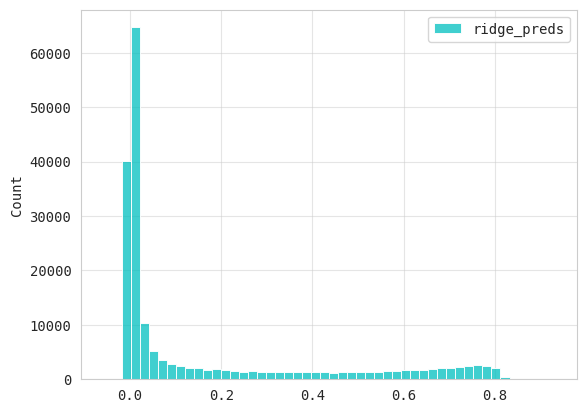

       id  PitNextLap
0  439140    0.002773
1  439141    0.023988
2  439142    0.004994
3  439143    0.245004
4  439144    0.659681
CPU times: user 3min 35s, sys: 21.9 s, total: 3min 57s
Wall time: 1min 37s


In [19]:
%%time

## ======== RIDGE CV ========
test_ridge, oof_ridge, score_ridge = train_meta(
    # clf='lasso',
    oof_df=oof_df,
    pred_df=pred_df,
    features=[*oof_df.columns],
    y_true=y_true,
)
print()
print(oof_ridge.shape, test_ridge.shape)

## -- Distribution Plots --
sns.histplot(test_ridge, label='ridge_preds', bins=50)
plt.legend()
plt.show()

submit[TARGET] = test_ridge
print(submit.head())

# np.save(f"oof_ridge_cvStack_{str(score_ridge).split('.')[1]}.npy", oof_ridge)
# np.save(f"test_ridge_cvStack_{str(score_ridge).split('.')[1]}.npy", test_ridge)
# submit.to_csv(f"submit_ridge_cvStack_{str(score_ridge).split('.')[1]}.csv", index=False)

===== Logistic 5 folds | Total Models: 149 =====
Converting to logits first...
Fold 1/5: 0.95605 | Best 'C': 0.04642
Fold 2/5: 0.95397 | Best 'C': 0.3594
Fold 3/5: 0.95500 | Best 'C': 0.3594
Fold 4/5: 0.95412 | Best 'C': 0.005995
Fold 5/5: 0.95562 | Best 'C': 0.005995

-------------------------
✅ Stacking AUC: 0.95494
-------------------------

(439140,) (188165,)


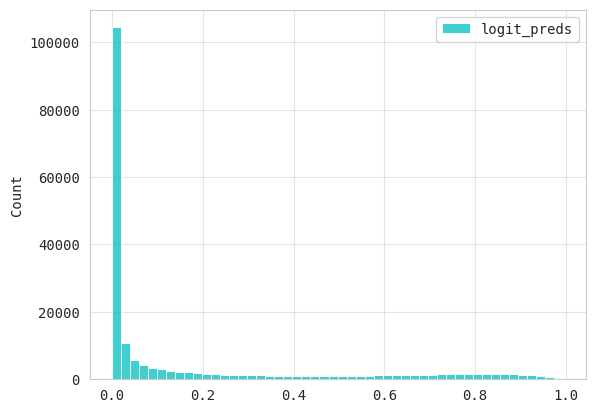

       id  PitNextLap
0  439140    0.003258
1  439141    0.016901
2  439142    0.004071
3  439143    0.303136
4  439144    0.719301
CPU times: user 35.1 s, sys: 6.84 s, total: 42 s
Wall time: 3min 47s


In [20]:
%%time

## ======== LOGISTIC CV ========
test_log, oof_log, score_logit = train_meta(
    clf='log',
    oof_df=oof_df,
    pred_df=pred_df,
    features=[*oof_df.columns],
    y_true=y_true,
    logit_first=True,
    # rank_first=True,
    # rank_logit=True,
)
print()
print(oof_log.shape, test_log.shape)

## -- Distribution Plots --
sns.histplot(test_log, label='logit_preds', bins=50)
plt.legend()
plt.show()

submit[TARGET] = test_log
print(submit.head())

# np.save(f"oof_logit_cvStack_{str(score_logit).split('.')[1]}.npy", oof_log)
# np.save(f"test_logit_cvStack_{str(score_logit).split('.')[1]}.npy", test_log)
# submit.to_csv(f"submit_logit_cvStack_{str(score_logit).split('.')[1]}.csv", index=False)

In [21]:
# log_raw_probas  = 🔴 STACKING AUC: 0.95408
# log_rank_first  = 🟠 STACKING AUC: 0.95468
# log_logit_first = 🟢 STACKING AUC: 0.95483

In [22]:
# !rm -r /kaggle/working

In [23]:
%%time

## -- Get all model scores --
model_scores = {}

for i, model_ in enumerate(oof_df.columns):
    # if i%10==0:
    print(f"\n {CFG.YELLOW}• Model {i+1}/{oof_df.shape[1]}: {model_}{CFG.RESET}")
    _, __, score = train_meta(
        clf='log',
        oof_df=oof_df,
        pred_df=pred_df,
        features=model_,
        y_true=y_true,
        # rank_first=True,
        logit_first=True,
        verbose=False,
    )

    model_scores[model_] = score


 • Model 1/149: knn_dis_None_91968
===== Logistic 5 folds | Total Models: 1 =====
Converting to logits first...

-------------------------
✅ Stacking AUC: 0.91952
-------------------------

 • Model 2/149: knn_dis_first_91953
===== Logistic 5 folds | Total Models: 1 =====
Converting to logits first...

-------------------------
✅ Stacking AUC: 0.91953
-------------------------

 • Model 3/149: knn_orig_dis_None_91732
===== Logistic 5 folds | Total Models: 1 =====
Converting to logits first...

-------------------------
✅ Stacking AUC: 0.91724
-------------------------

 • Model 4/149: knn_orig_dis_first_91719
===== Logistic 5 folds | Total Models: 1 =====
Converting to logits first...

-------------------------
✅ Stacking AUC: 0.91708
-------------------------

 • Model 5/149: knn_orig_uni_None_91679
===== Logistic 5 folds | Total Models: 1 =====
Converting to logits first...

-------------------------
✅ Stacking AUC: 0.91669
-------------------------

 • Model 6/149: knn_orig_uni_fir

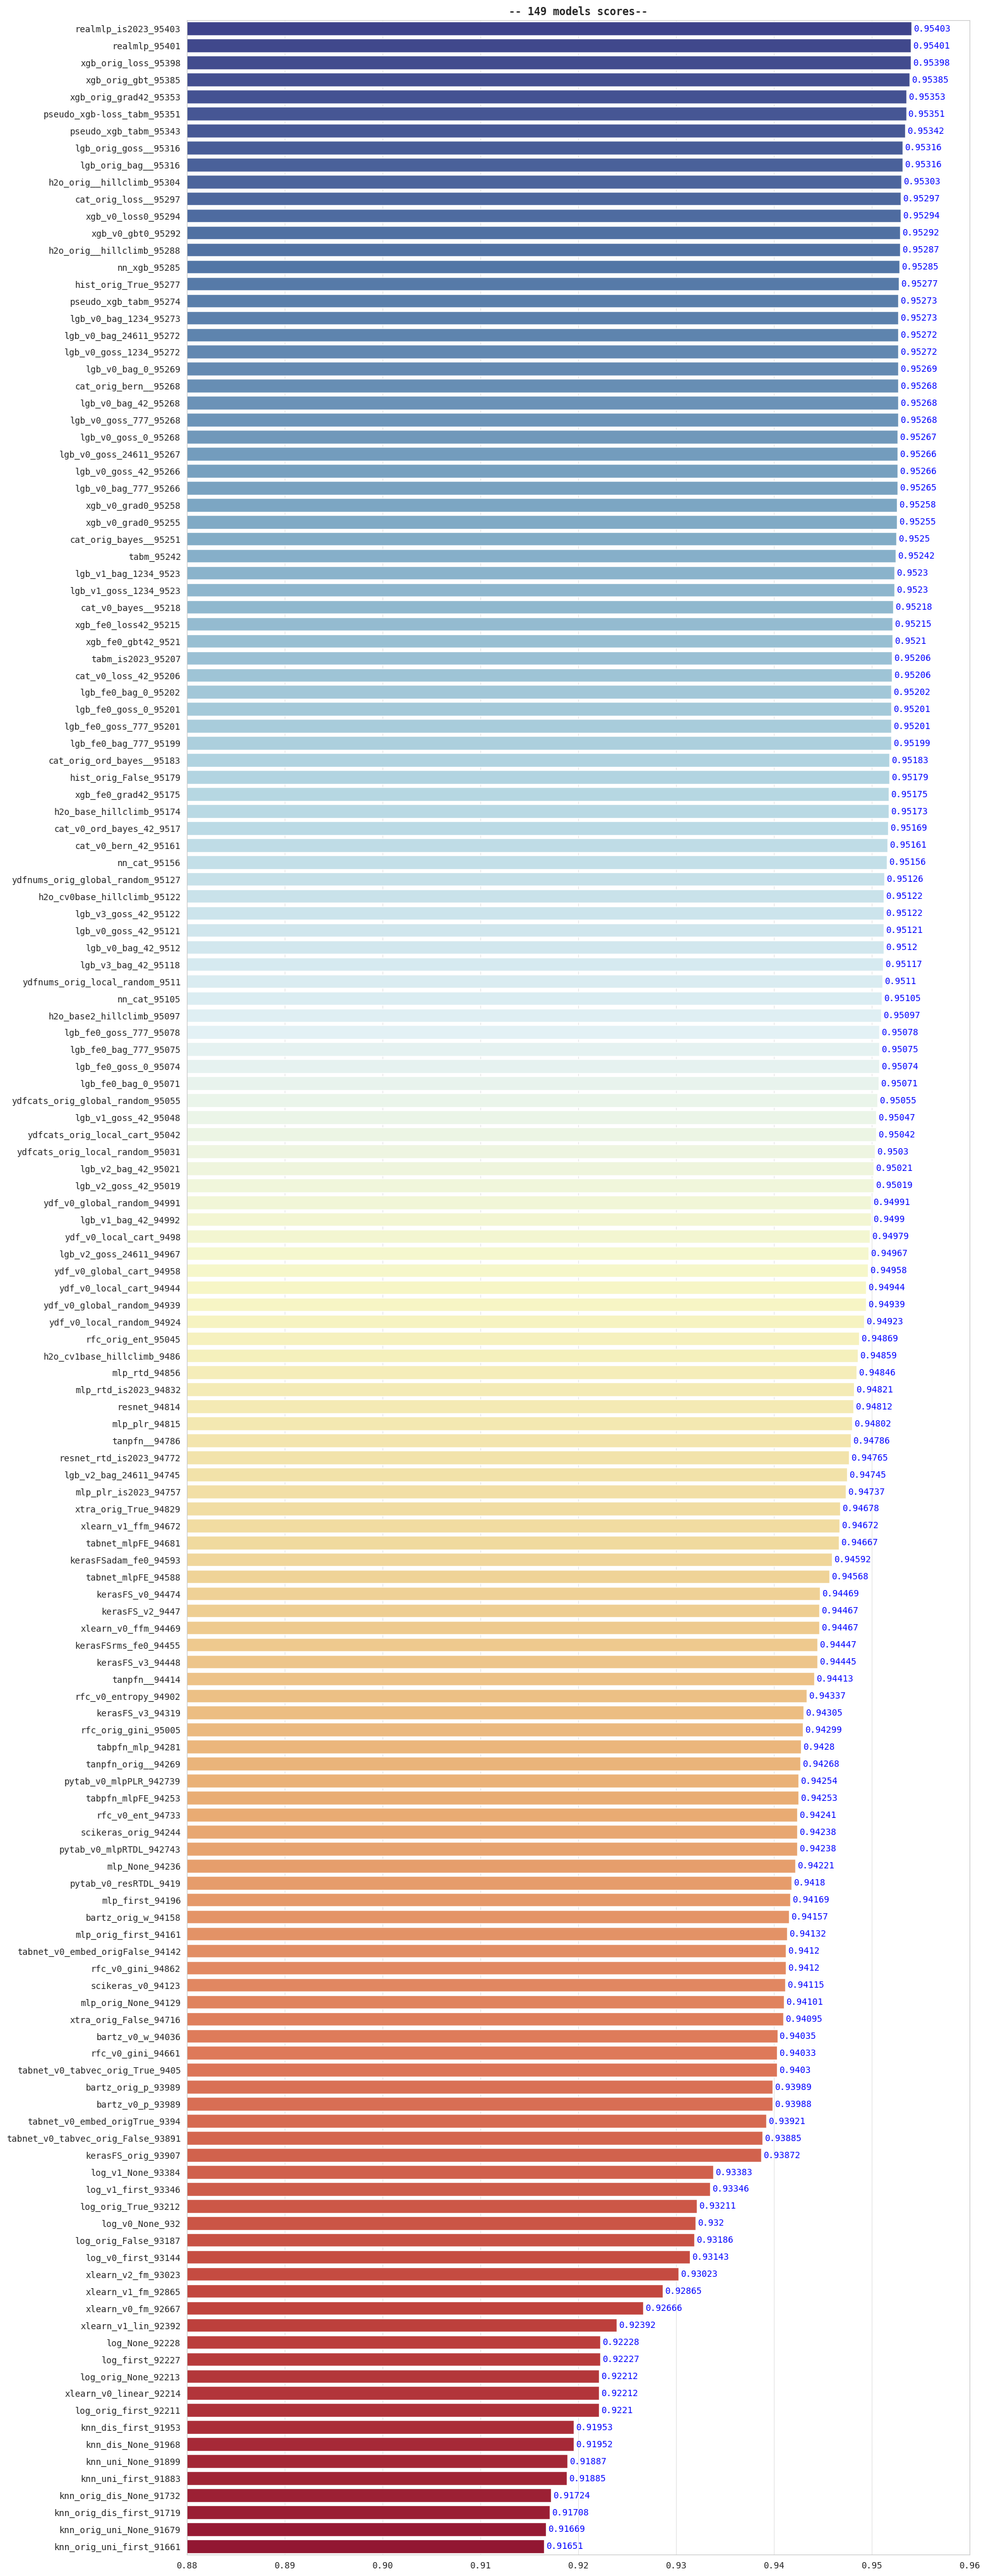

In [24]:
## -- Plot model scores --
model_scores_df = pd.Series(model_scores).sort_values(ascending=False)

plt.figure(figsize=(16, len(model_scores)*0.35))
sns.barplot(model_scores_df, orient='h', palette='RdYlBu_r', native_scale=True)

for i, score in enumerate(model_scores_df.values):
    plt.text(score+2e-4, model_scores_df.index[i], np.round(score, 5), ha='left', va='center', color='b')

plt.title(f'-- {len(model_scores_df)} models scores--', fontweight='semibold')
plt.xlim(.88, .96)
# plt.tight_layout()
plt.show()

In [25]:
print(f"Top model: {model_scores_df.index[0]}")

Top model: realmlp_is2023_95403


In [26]:
rng = np.random.default_rng()

all_scores = {}
all_models = {}

for i in tqdm(range(len(model_scores_df[:3])), desc='Train stage'): 

    all_models_local = model_scores_df.index.tolist()
    models_id  = [_ for _ in range(len(model_scores_df))]

    # 1. Start sequentially 0, 1, 2...
    # init_model = all_models_local[i]

    # 2. Always start with best model
    init_model = all_models_local[0]

    best_models = []
    best_score  = round(roc_auc_score(y_true, oof_df[init_model]), 5)

    _id = models_id.pop(0)
    other_models = [all_models_local[_] for _ in models_id]
    other_models = rng.permutation(other_models).tolist()

    print(f"\nStarting with {init_model} ------")

    for j, m in enumerate(other_models):
        # print('Initial model', init_model); print('Added model', m)
        total_models = best_models + [init_model] + [m]
        # print('Total models', total_models)

        print(f"\t{j+1}/{len(other_models)} ++ Added {m}")
        print('-'*70)
        _, __, _score = train_meta(
            clf='log',
            oof_df=oof_df,
            pred_df=pred_df,
            y_true=y_true,
            features=total_models,
            logit_first=True,
            verbose=False,
        )

        if _score > best_score:
            best_score = _score
            best_models.append(m)
            print(f"{CFG.GREEN}✓ {m} -> improved: {_score}{CFG.RESET}\n")
        else:
            print(f"{CFG.YELLOW}✕ {m} -> depreciate: {_score}{CFG.RESET}\n")

    print(f"\nBest score: {best_score:.5f}")
    print(f"Best models: {len(best_models)}\n{best_models}\n")

    best_models.append(init_model)

    all_scores[i] = best_score
    all_models[i] = best_models

Train stage:   0%|          | 0/3 [00:00<?, ?it/s]


Starting with realmlp_is2023_95403 ------
	1/148 ++ Added cat_v0_loss_42_95206
----------------------------------------------------------------------
===== Logistic 5 folds | Total Models: 2 =====
Converting to logits first...

-------------------------
✅ Stacking AUC: 0.95436
-------------------------
✓ cat_v0_loss_42_95206 -> improved: 0.95436

	2/148 ++ Added h2o_base_hillclimb_95174
----------------------------------------------------------------------
===== Logistic 5 folds | Total Models: 3 =====
Converting to logits first...

-------------------------
✅ Stacking AUC: 0.95444
-------------------------
✓ h2o_base_hillclimb_95174 -> improved: 0.95444

	3/148 ++ Added cat_v0_ord_bayes_42_9517
----------------------------------------------------------------------
===== Logistic 5 folds | Total Models: 4 =====
Converting to logits first...

-------------------------
✅ Stacking AUC: 0.95444
-------------------------
✕ cat_v0_ord_bayes_42_9517 -> depreciate: 0.95444

	4/148 ++ Added lg

In [27]:
all_scores

{0: np.float64(0.95492), 1: np.float64(0.95492), 2: np.float64(0.95492)}

In [28]:
best_idx = np.argsort([float(c) for c in all_scores.values()])[-1]

best_score = all_scores[best_idx]
best_models = all_models[best_idx]

print(f"Best run score: {best_score}")
print(f"Total models selected: {len(best_models)}")

best_models

Best run score: 0.95492
Total models selected: 18


['xlearn_v1_lin_92392',
 'h2o_orig__hillclimb_95304',
 'h2o_orig__hillclimb_95288',
 'xgb_fe0_loss42_95215',
 'log_v1_None_93384',
 'xgb_orig_loss_95398',
 'lgb_v2_bag_24611_94745',
 'knn_orig_uni_first_91661',
 'realmlp_95401',
 'rfc_orig_gini_95005',
 'ydf_v0_global_random_94939',
 'cat_orig_ord_bayes__95183',
 'lgb_v1_bag_42_94992',
 'log_orig_False_93187',
 'log_None_92228',
 'nn_cat_95156',
 'nn_cat_95105',
 'realmlp_is2023_95403']

In [29]:
# Best score: 0.95494
# Best models: 23
# best_models = ['knn_dis_first_91953', 'rfc_v0_gini_94862', 'lgb_v0_goss_42_95266', 'knn_orig_uni_first_91661',
#                'mlp_rtd_94856', 'xgb_orig_loss_95398', 'lgb_v1_goss_1234_9523', 'h2o_orig__hillclimb_95304',
#                'xgb_v0_loss0_95294', 'lgb_v1_bag_42_94992', 'nn_cat_95156', 'lgb_fe0_goss_777_95078',
#                'nn_cat_95105', 'scikeras_orig_94244', 'ydf_v0_local_random_94924', 'h2o_orig__hillclimb_95288',
#                'log_v0_first_93144', 'lgb_v2_bag_24611_94745', 'ydfcats_orig_local_random_95031',
#                'xlearn_v1_fm_92865', 'log_None_92228', 'xtra_orig_True_94829', 'realmlp_95401'] + ['realmlp_95401']

### KERAS

===== Keras 5 folds | Total Models: 18 =====
Epoch 1/10


2026-06-01 02:20:07.299956: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


5490/5490 ━━━━━━━━━━━━━━━━━━━━ 13s 2ms/step - auc: 0.9431 - loss: 0.2419
Epoch 2/10
5490/5490 ━━━━━━━━━━━━━━━━━━━━ 12s 2ms/step - auc: 0.9528 - loss: 0.2307
Epoch 3/10
5490/5490 ━━━━━━━━━━━━━━━━━━━━ 12s 2ms/step - auc: 0.9528 - loss: 0.2306
Epoch 4/10
5490/5490 ━━━━━━━━━━━━━━━━━━━━ 12s 2ms/step - auc: 0.9528 - loss: 0.2306
Epoch 5/10
5490/5490 ━━━━━━━━━━━━━━━━━━━━ 12s 2ms/step - auc: 0.9527 - loss: 0.2306
Epoch 6/10
5490/5490 ━━━━━━━━━━━━━━━━━━━━ 13s 2ms/step - auc: 0.9527 - loss: 0.2306
Epoch 7/10
5490/5490 ━━━━━━━━━━━━━━━━━━━━ 12s 2ms/step - auc: 0.9527 - loss: 0.2306
Epoch 8/10
5490/5490 ━━━━━━━━━━━━━━━━━━━━ 12s 2ms/step - auc: 0.9527 - loss: 0.2306
Epoch 9/10
5490/5490 ━━━━━━━━━━━━━━━━━━━━ 13s 2ms/step - auc: 0.9527 - loss: 0.2306
Epoch 10/10
5490/5490 ━━━━━━━━━━━━━━━━━━━━ 12s 2ms/step - auc: 0.9527 - loss: 0.2306
1373/1373 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step
2941/2941 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step
 ℹ️ Fold 1/5: 0.95565

Epoch 1/10
5490/5490 ━━━━━━━━━━━━━━━━━━━━ 13s 2ms/step - auc:

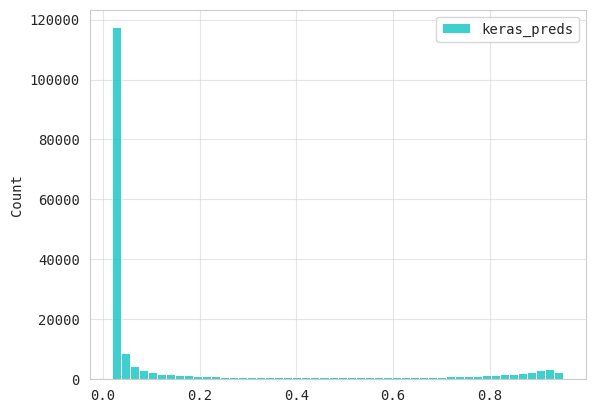

       id  PitNextLap
0  439140    0.023748
1  439141    0.027628
2  439142    0.023958
3  439143    0.177413
4  439144    0.840870
CPU times: user 14min 55s, sys: 1min 22s, total: 16min 18s
Wall time: 10min 50s


In [30]:
%%time

## ======== KERAS CV ========
test_keras, oof_keras, score_keras = train_meta(
    clf='keras',
    oof_df=oof_df,
    pred_df=pred_df,
    features=best_models,
    y_true=y_true,
)
print()
print(oof_keras.shape, test_keras.shape)

## -- Distribution Plots --
sns.histplot(test_keras, label='keras_preds', bins=50)
plt.legend()
plt.show()

submit[TARGET] = test_keras
print(submit.head())

keras_ = 'keras_cvStack'
np.save(f"oof_{keras_}_{str(score_keras).split('.')[1]}.npy", oof_keras)
np.save(f"test_{keras_}_{str(score_keras).split('.')[1]}.npy", test_keras)
submit.to_csv(f"submit_{keras_}_{str(score_keras).split('.')[1]}.csv", index=False)

### RIDGE

===== Ridge 5 folds | Total Models: 18 =====
Fold 1/5: 0.95589 | Best Alpha: 10.0
Fold 2/5: 0.95381 | Best Alpha: 10.0
Fold 3/5: 0.95492 | Best Alpha: 10.0
Fold 4/5: 0.95415 | Best Alpha: 10.0
Fold 5/5: 0.95569 | Best Alpha: 10.0

-------------------------
✅ Stacking AUC: 0.95488
-------------------------

(439140,) (188165,)


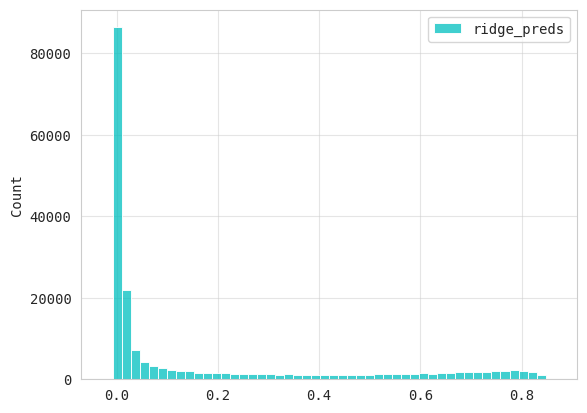

       id  PitNextLap
0  439140    0.003125
1  439141    0.016755
2  439142    0.005049
3  439143    0.251152
4  439144    0.675333
CPU times: user 49.6 s, sys: 88.3 ms, total: 49.7 s
Wall time: 14.6 s


In [31]:
%%time

## ======== RIDGE CV ========
test_ridge, oof_ridge, score_ridge = train_meta(
    # clf='lasso',
    oof_df=oof_df,
    pred_df=pred_df,
    features=best_models, 
    y_true=y_true,
)
print()
print(oof_ridge.shape, test_ridge.shape)

## -- Distribution Plots --
sns.histplot(test_ridge, label='ridge_preds', bins=50)
plt.legend()
plt.show()

submit[TARGET] = test_ridge
print(submit.head())

ridge_ = 'ridge_cvStack'

np.save(f"oof_{ridge_}_{str(score_ridge).split('.')[1]}.npy", oof_ridge)
np.save(f"test_{ridge_}_{str(score_ridge).split('.')[1]}.npy", test_ridge)
submit.to_csv(f"submit_{ridge_}_{str(score_ridge).split('.')[1]}.csv", index=False)

In [32]:
%%time

## -- Train on full data --
ridge_clf = RidgeCV(alphas=(0.1, 1.0, 10.0, 100.0, 1000.0), scoring='neg_mean_squared_error', cv=5)
ridge_clf.fit(oof_df[best_models], y_true)

## -- Make submission --
sub_name = f"ridge_stackFULL_{str(score_ridge).split('.')[1]}"
submit[TARGET] = ridge_clf.predict(pred_df[best_models])
submit.to_csv(f"submit_{sub_name}.csv", index=False)

print('Ridge Submission File Exported -> ', sub_name)
submit.head()

Ridge Submission File Exported ->  ridge_stackFULL_95488
CPU times: user 11.7 s, sys: 4.98 ms, total: 11.7 s
Wall time: 3.39 s


,id,PitNextLap
0,439140,0.003129
1,439141,0.016763
2,439142,0.005056
3,439143,0.251278
4,439144,0.675218


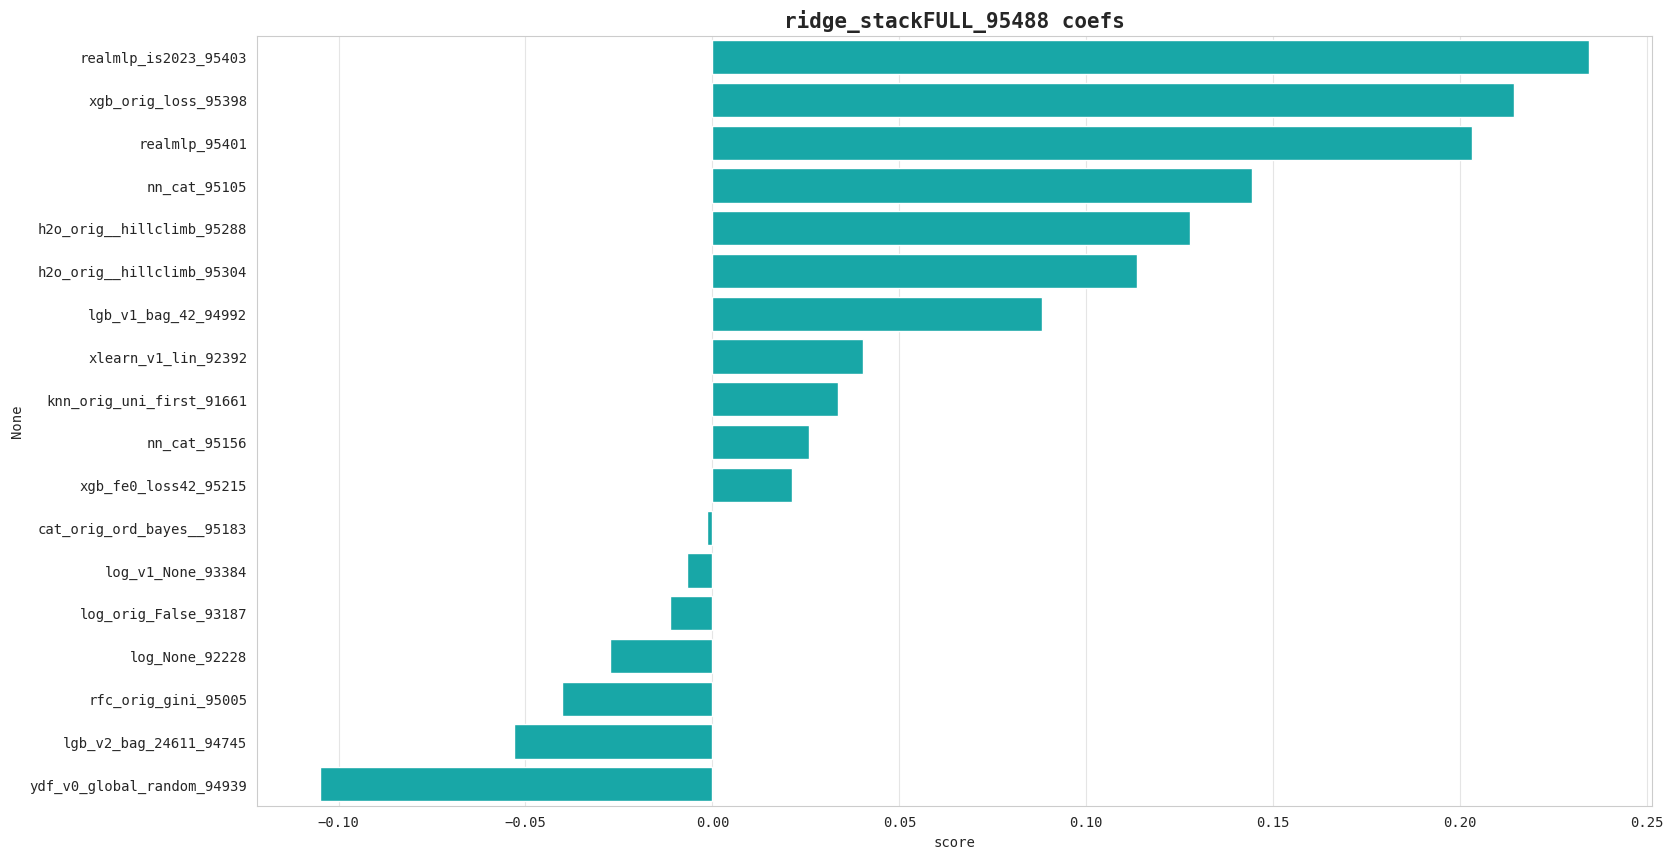

In [33]:
# oof_df[list(set(n_selected))]
ridge_table = pd.DataFrame\
    .from_dict(dict(zip(oof_df[best_models], ridge_clf.coef_)), orient='index')\
    .rename(columns={0: 'score'}).sort_values('score', ascending=False) #[:50]

plt.figure(figsize=(18, 10))
sns.barplot(ridge_table, x='score', y=ridge_table.index)
plt.title(f"{sub_name} coefs", fontdict={'size': 15, 'weight': 'semibold'})
# plt.tight_layout()

plt.savefig('ridge_oof_coef')
plt.show()

In [34]:
ridge_features = ridge_table[ridge_table.values > 0].index.tolist()
print('Top features by Ridge:', len(ridge_features))

Top features by Ridge: 11


## LINEAR REGRESSION

===== LinReg 5 folds | Total Models: 18 =====
Fold 1/5: 0.95589
Fold 2/5: 0.95381
Fold 3/5: 0.95492
Fold 4/5: 0.95415
Fold 5/5: 0.95568

-------------------------
✅ Stacking AUC: 0.95488
-------------------------

(439140,) (188165,)


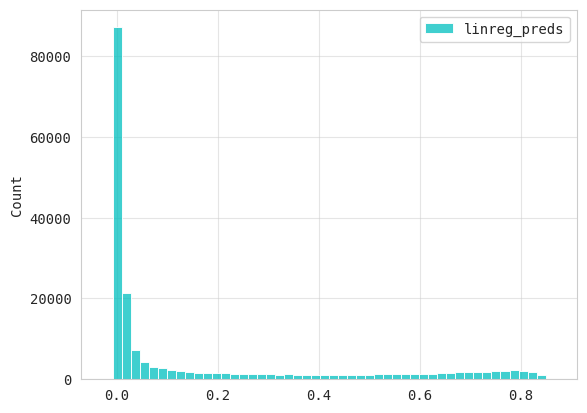

       id  PitNextLap
0  439140    0.003120
1  439141    0.016756
2  439142    0.005061
3  439143    0.251407
4  439144    0.674407
CPU times: user 6.63 s, sys: 24.2 ms, total: 6.66 s
Wall time: 3.17 s


In [35]:
%%time

## ======== LINEAR CV ========
test_linreg, oof_linreg, score_linreg = train_meta(
    clf='linreg',
    oof_df=oof_df,
    pred_df=pred_df,
    features=best_models,
    y_true=y_true,
)
print()
print(oof_linreg.shape, test_linreg.shape)

## -- Distribution Plots --
sns.histplot(test_linreg, label='linreg_preds', bins=50)
plt.legend()
plt.show()

submit[TARGET] = test_linreg
print(submit.head())

linreg_ = 'linreg_cvStack'

np.save(f"oof_{linreg_}_{str(score_linreg).split('.')[1]}.npy", oof_linreg)
np.save(f"test_{linreg_}_{str(score_linreg).split('.')[1]}.npy", test_linreg)
submit.to_csv(f"submit_{linreg_}_{str(score_linreg).split('.')[1]}.csv", index=False)

In [36]:
%%time

## -- Train on full data --
linreg_clf = LinearRegression(n_jobs=os.cpu_count())
linreg_clf.fit(oof_df[best_models], y_true)

## -- Make submission --
sub_name = f"linreg_stackFULL_{str(score_linreg).split('.')[1]}"
submit[TARGET] = linreg_clf.predict(pred_df[best_models])
submit.to_csv(f"submit_{sub_name}.csv", index=False)

print('Linear Regression submission file exported -> ', sub_name)
submit.head()

Linear Regression submission file exported ->  linreg_stackFULL_95488
CPU times: user 1.76 s, sys: 38.5 ms, total: 1.8 s
Wall time: 933 ms


,id,PitNextLap
0,439140,0.003125
1,439141,0.016764
2,439142,0.005066
3,439143,0.251489
4,439144,0.674482


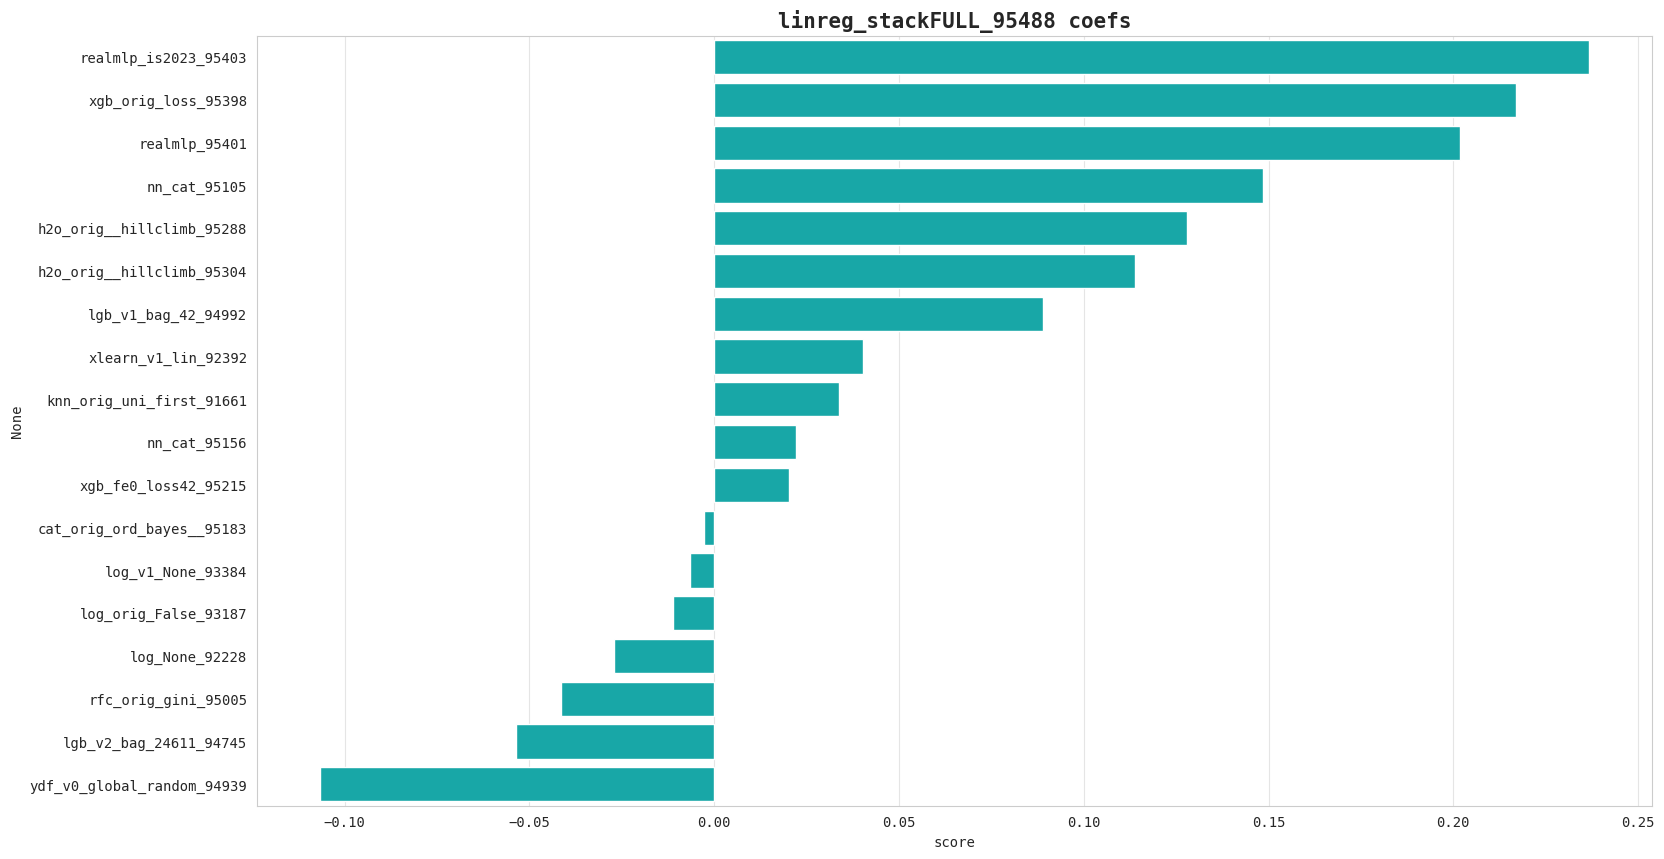

In [37]:
## -- Plot feature coefs --
linreg_table = pd.DataFrame\
    .from_dict(dict(zip(oof_df[best_models], linreg_clf.coef_)), orient='index')\
    .rename(columns={0: 'score'}).sort_values('score', ascending=False) #[:50]

plt.figure(figsize=(18, 10))
sns.barplot(linreg_table, x='score', y=linreg_table.index)
plt.title(f"{sub_name} coefs", fontdict={'size': 15, 'weight': 'semibold'})

# plt.tight_layout()
plt.savefig('lin_oof_coef')
plt.show()

In [38]:
linreg_features = linreg_table[linreg_table.values > 0].index.tolist()
print('Top features by LinearReg:', len(linreg_features))

Top features by LinearReg: 11


## LOGISTIC REGRESSION

===== Logistic 5 folds | Total Models: 18 =====
Converting to logits first...
Fold 1/5: 0.95598 | Best 'C': 0.04642
Fold 2/5: 0.95390 | Best 'C': 0.04642
Fold 3/5: 0.95498 | Best 'C': 0.3594
Fold 4/5: 0.95417 | Best 'C': 0.04642
Fold 5/5: 0.95563 | Best 'C': 0.3594

-------------------------
✅ Stacking AUC: 0.95492
-------------------------

(439140,) (188165,)


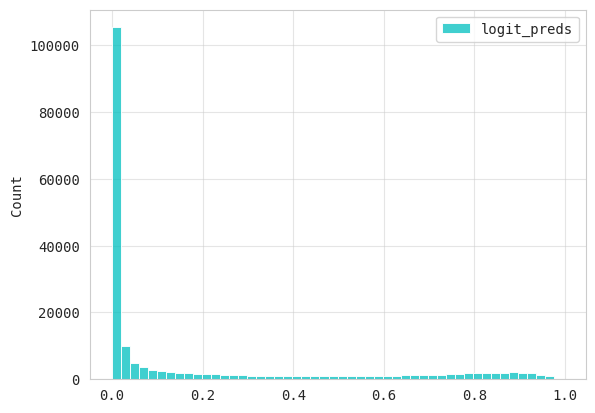

       id  PitNextLap
0  439140    0.003006
1  439141    0.015509
2  439142    0.003642
3  439143    0.308018
4  439144    0.784179
CPU times: user 9.13 s, sys: 452 ms, total: 9.58 s
Wall time: 47 s


In [39]:
%%time

## ======== LOGISTIC CV ========
test_log, oof_log, score_logit = train_meta(
    clf='log',
    oof_df=oof_df,
    pred_df=pred_df,
    features=best_models,
    y_true=y_true,
    logit_first=True,
)
print()
print(oof_log.shape, test_log.shape)

## -- Distribution Plots --
sns.histplot(test_log, label='logit_preds', bins=50)
plt.legend()
plt.show()

submit[TARGET] = test_log
print(submit.head())

logit_ = 'logit_cvStack'

np.save(f"oof_{logit_}_{str(score_logit).split('.')[1]}.npy", oof_log)
np.save(f"test_{logit_}_{str(score_logit).split('.')[1]}.npy", test_log)
submit.to_csv(f"submit_{logit_}_{str(score_logit).split('.')[1]}.csv", index=False)

In [40]:
%%time

## -- Train on full data --
log_clf = LogisticRegressionCV(
    max_iter=10_000,
    cv=5,
    tol=1e-4,
    scoring='roc_auc',
    n_jobs=os.cpu_count(),
    random_state=CFG.SEED,
)

log_clf.fit(oof_df[best_models], y_true) 

## -- Make submission --
sub_name = f"logit_stackFULL_{str(score_logit).split('.')[1]}"
submit[TARGET] = log_clf.predict_proba(pred_df[best_models])[:, 1]
submit.to_csv(f"submit_{sub_name}.csv", index=False)

print('Logistic submission file exported -> ', sub_name)
submit.head()

Logistic submission file exported ->  logit_stackFULL_95492
CPU times: user 1.47 s, sys: 78.8 ms, total: 1.55 s
Wall time: 7.22 s


,id,PitNextLap
0,439140,0.024049
1,439141,0.027432
2,439142,0.024252
3,439143,0.159939
4,439144,0.827026


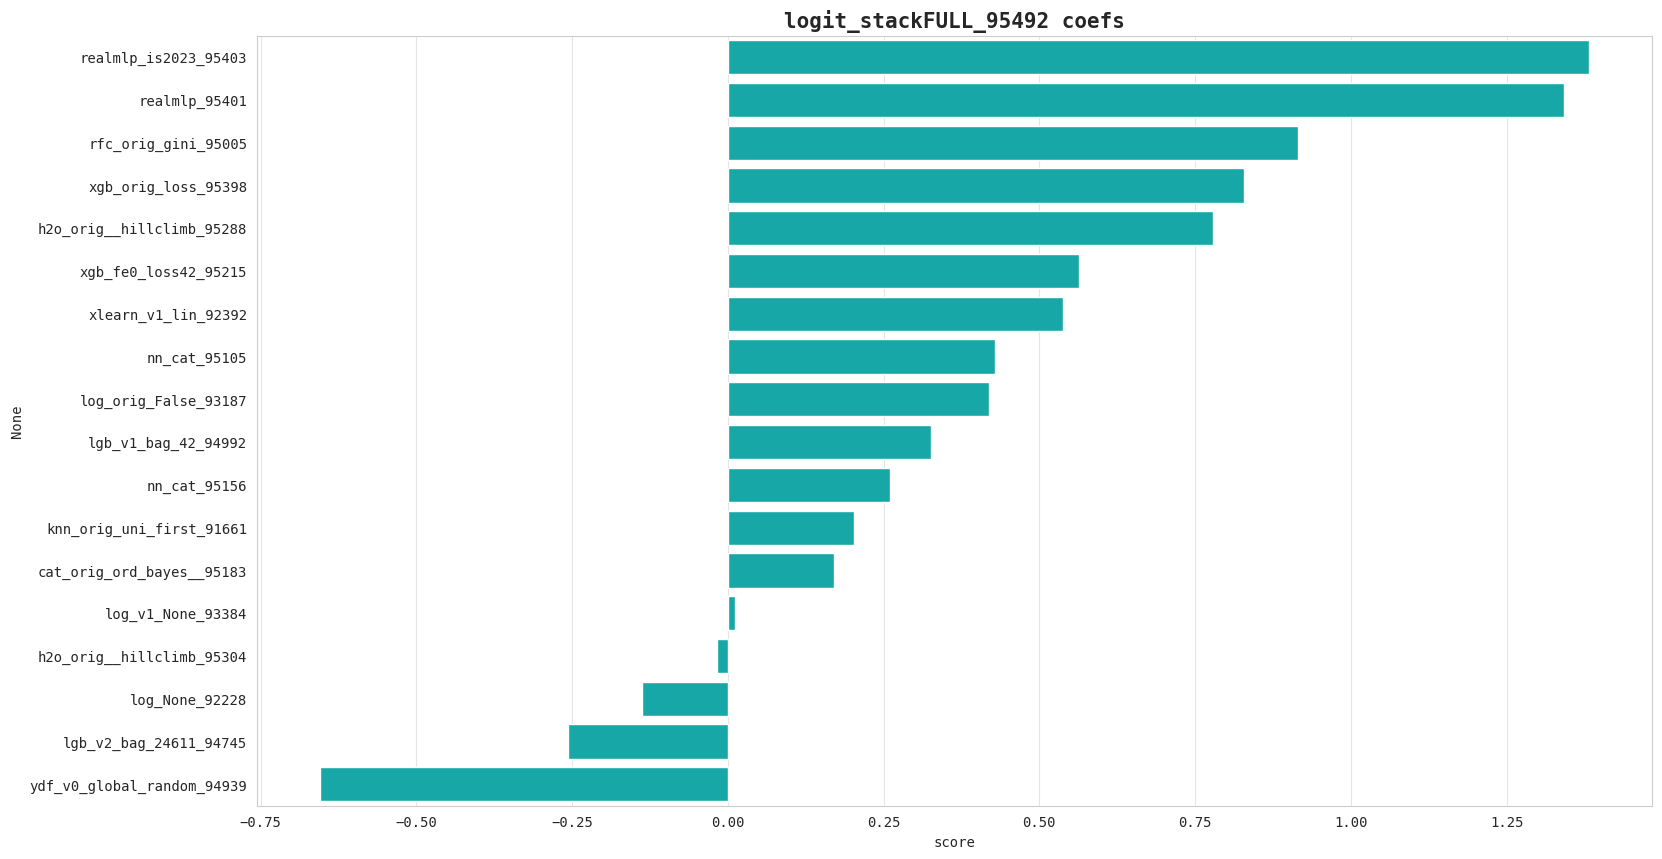

In [41]:
## -- PLOT FEATURE COEFs --
log_table = pd.DataFrame\
    .from_dict(dict(zip(oof_df[best_models], log_clf.coef_[0])), orient='index')\
    .rename(columns={0: 'score'}).sort_values('score', ascending=False)

plt.figure(figsize=(18, 10))
sns.barplot(log_table, x='score', y=log_table.index)
plt.title(f"{sub_name} coefs", fontdict={'size': 15, 'weight': 'semibold'})

# plt.tight_layout()
plt.savefig('logit_oof_coef')
plt.show()

In [42]:
log_features = log_table[log_table.values > 0].index.tolist()
print('Top features by Logistic:', len(log_features))

Top features by Logistic: 14


### BAYESIAN

===== Bayesian 5 folds | Total Models: 18 =====
Fold 1/5: 0.95589
Fold 2/5: 0.95381
Fold 3/5: 0.95492
Fold 4/5: 0.95415
Fold 5/5: 0.95568

-------------------------
✅ Stacking AUC: 0.95488
-------------------------

(439140,) (188165,)


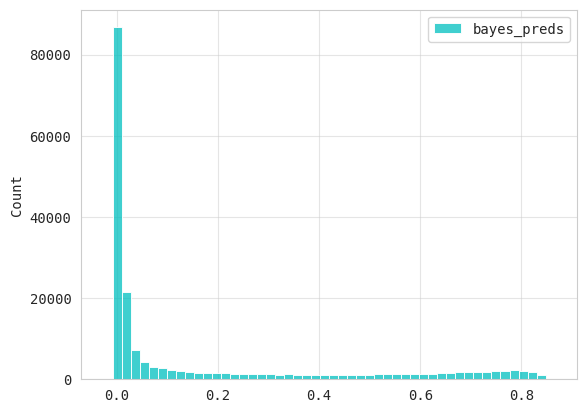

       id  PitNextLap
0  439140    0.003123
1  439141    0.016755
2  439142    0.005055
3  439143    0.251267
4  439144    0.674895
CPU times: user 11 s, sys: 23 ms, total: 11 s
Wall time: 4.14 s


In [43]:
%%time

## ======== BAYESIAN CV ========
test_bayes, oof_bayes, score_bayes = train_meta(
    clf='bayes',
    oof_df=oof_df,
    pred_df=pred_df,
    features=best_models,
    y_true=y_true.astype(float),
    # rank_first=True,
)
print()

print(oof_bayes.shape, test_bayes.shape)

## -- Distribution Plots --
sns.histplot(test_bayes, label='bayes_preds', bins=50)
plt.legend()
plt.show()

submit[TARGET] = test_bayes
print(submit.head())

bayes_ = 'bayes_cvStack'
np.save(f"oof_{bayes_}_cvStack_{str(score_bayes).split('.')[1]}.npy", oof_bayes)
np.save(f"test_{bayes_}_cvStack_{str(score_bayes).split('.')[1]}.npy", test_bayes)
submit.to_csv(f"submit_{bayes_}_cvStack_{str(score_bayes).split('.')[1]}.csv", index=False)

In [44]:
%%time

## -- Train on full data --
bayes_clf = BayesianRidge(max_iter=10_000, tol=1e-4)
bayes_clf.fit(oof_df[best_models], y_true.astype(float))

## -- Make submission --
sub_name = f"bayes_stackFULL_{str(score_bayes).split('.')[1]}"
submit[TARGET] = bayes_clf.predict(pred_df[best_models])
# submit.to_csv(f"submit_{sub_name}.csv", index=False)

print('Bayesian submission file exported -> ', sub_name)
submit.head()

Bayesian submission file exported ->  bayes_stackFULL_95488
CPU times: user 1.68 s, sys: 5.05 ms, total: 1.69 s
Wall time: 478 ms


,id,PitNextLap
0,439140,0.003127
1,439141,0.016764
2,439142,0.005061
3,439143,0.251372
4,439144,0.674874


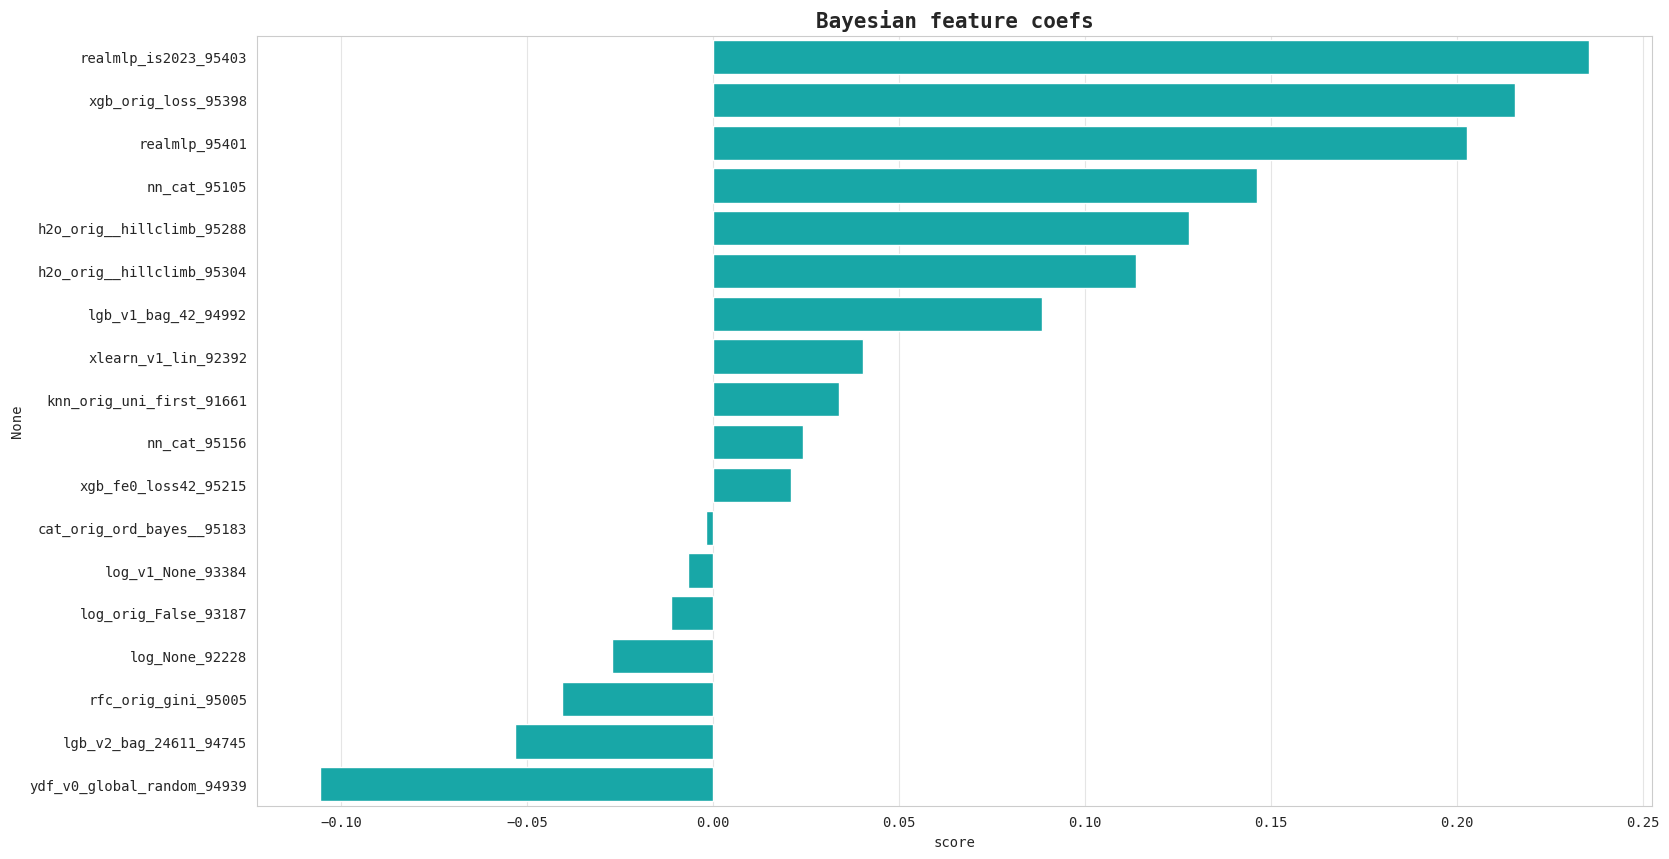

In [45]:
## -- Plot feature coefs --
bayes_table = pd.DataFrame\
    .from_dict(dict(zip(oof_df[best_models], bayes_clf.coef_)), orient='index')\
    .rename(columns={0: 'score'}).sort_values('score', ascending=False) #[:50]

plt.figure(figsize=(18, 10))
sns.barplot(bayes_table, x='score', y=bayes_table.index)
plt.title('Bayesian feature coefs', fontdict={'size': 15, 'weight': 'semibold'})
# plt.tight_layout()
plt.savefig('bayes_oof_coef')
plt.show()

In [46]:
bayes_features = bayes_table[bayes_table.values > 0].index.tolist()
print('Top features by Bayesian:', len(bayes_features))

Top features by Bayesian: 11


### MLP

In [47]:
# %%time
# ## ======== MLP CV ========
# test_mlp, oof_mlp, mlp_score = train_meta(
#     clf='mlp',
#     oof_df=oof_df,
#     pred_df=pred_df,
#     features=list(set(n_selected)),
#     y_true=y_true,
#     # kf_splits=5,
# )
# print()

# print(oof_mlp.shape, test_mlp.shape)

# ## -- Distribution Plots --
# # sns.histplot(oof_mlp, label='OOF', bins=50)
# sns.histplot(test_mlp, label='TEST', bins=50)
# plt.legend()
# plt.show()

# np.save(f"oof_mlp_cvStack_{str(mlp_score).split('.')[1]}.npy", oof_mlp)
# np.save(f"test_mlp_cvStack_{str(mlp_score).split('.')[1]}.npy", test_mlp)

# # submit[TARGET] = test_mlp
# # submit.to_csv(f"submit_mlp_stack_{str(mlp_score).split('.')[1]}.csv", index=False)
# # submit.head()

In [48]:
# %%time
# ## -- TRAIN ON FULL DATA --
# mlp_clf = MLPRegressor(max_iter=1000, hidden_layer_sizes=(150,), tol=1e-5, random_state=CFG.SEED)
# mlp_clf.fit(oof_df[list(set(n_selected))], y_true)

# ## -- MAKE SUBMISSION --
# n = f"submit_mlp_stackFULL_{str(mlp_score).split('.')[1]}.csv"
# submit[TARGET] = mlp_clf.predict(pred_df[list(set(n_selected))])
# submit.to_csv(n, index=False)

# print('MLP Submission File Exported -> ', n)
# submit.head()

In [49]:
# ## -- PLOT FEATURE COEFs --
# mlp_table = pd.DataFrame\
#               .from_dict(dict(zip(oof_df[list(set(n_selected))].columns, mlp_clf.coefs_[0][0])), orient='index')\
#               .rename(columns={0: 'score'}).sort_values('score', ascending=False)

# plt.figure(figsize=(18, 10))
# sns.barplot(mlp_table[:30], x='score', y=mlp_table[:30].index)
# plt.title('MLP FEATURE COEFs SCORES', fontdict={'size': 15, 'weight': 'semibold'})

# # plt.tight_layout()
# plt.savefig('mlp_oof_coef')
# plt.show()

In [50]:
# mlp_features = mlp_table[mlp_table.values > 0].index.tolist()
# print('Top features by MLP:', len(mlp_features))

### ELASTIC NET

In [51]:
# %%time
# ## ======== ELASTIC NET CV ========
# test_elastic, oof_elastic, score_elastic = train_meta(
#     clf='elastic',
#     oof_df=oof_df,
#     pred_df=pred_df,
#     features=list(set(n_selected)),
#     y_true=y_true,
#     n_cv=5,
# )
# print()

# print(oof_elastic.shape, test_elastic.shape)

# ## -- Distribution Plots --
# sns.histplot(test_elastic, label='TEST', bins=50)
# plt.legend()
# plt.show()

# np.save(f"oof_elastic_cvStack_{str(score_elastic).split('.')[1]}.npy", oof_elastic)
# np.save(f"test_elastic_cvStack_{str(score_elastic).split('.')[1]}.npy", test_elastic)

# # submit[TARGET] = test_elastic
# # submit.to_csv(f"submit_elastic_stack_{str(score_elastic).split('.')[1]}.csv", index=False)
# # submit.head()

In [52]:
# %%time
# ## -- TRAIN ON FULL DATA --
# elastic_clf = ElasticNetCV(cv=5, tol=1e-5, n_jobs=os.cpu_count(), random_state=CFG.SEED)
# elastic_clf.fit(oof_df[list(set(n_selected))], y_true)

# # _ = np.round(roc_auc_score(y_true, elastic_clf.predict(oof_df)), 6)

# ## -- MAKE SUBMISSION --
# n = f"submit_elastic_stackFULL_{str(score_elastic).split('.')[1]}.csv"
# submit[TARGET] = elastic_clf.predict(pred_df[list(set(n_selected))])
# submit.to_csv(n, index=False)

# print('Elastic Submission File Exported -> ', n)
# submit.head()

In [53]:
# ## -- PLOT FEATURE COEFS --
# elastic_table = pd.DataFrame\
#                 .from_dict(dict(zip(oof_df[list(set(n_selected))].columns, elastic_clf.coef_)), orient='index')\
#                 .rename(columns={0: 'score'}).sort_values('score', ascending=False)

# plt.figure(figsize=(15, 8))
# sns.barplot(elastic_table[:30], x='score', y=elastic_table[:30].index)
# plt.title('ELASTIC NET FEATURE COEFs', fontdict={'size': 15, 'weight': 'semibold'})

# # plt.tight_layout()
# plt.savefig('elastic_oof_coef')
# plt.show()

In [54]:
# elastic_features = elastic_table[elastic_table.values > 0].index.tolist()
# print('Top features by ElasticNet:', len(elastic_features))

### LASSO

In [55]:
# %%time
# ## ======== LASSO CV ========
# test_lasso, oof_lasso, lasso_score = train_meta(
#     clf='lasso',
#     oof_df=oof_df,
#     pred_df=pred_df,
#     features=list(set(n_selected)),
#     y_true=y_true,
#     n_cv=5,
# )
# print()
# print(oof_lasso.shape, test_lasso.shape)

# ## -- Distribution Plots --
# # sns.histplot(oof_lasso, label='OOF', bins=50)
# sns.histplot(test_lasso, label='TEST', bins=50)
# plt.legend()
# plt.show()

# np.save(f"oof_lasso_cvStack_{str(lasso_score).split('.')[1]}.npy", oof_lasso)
# np.save(f"test_lasso_cvStack_{str(lasso_score).split('.')[1]}.npy", test_lasso)

# # submit[TARGET] = test_lasso
# # submit.to_csv(f"submit_ridge_stackCV_{str(lasso_score).split('.')[1]}.csv", index=False)
# # submit.head()

In [56]:
# %%time
# ## -- TRAIN ON FULL DATA --
# lasso_clf = LassoCV(alphas=20, cv=5, tol=1e-5, n_jobs=os.cpu_count(), random_state=CFG.SEED)
# lasso_clf.fit(oof_df[list(set(n_selected))], y_true)

# ## -- MAKE SUBMISSION --
# n = f"submit_lasso_stackFULL_{str(lasso_score).split('.')[1]}.csv"
# submit[TARGET] = lasso_clf.predict(pred_df[list(set(n_selected))])
# submit.to_csv(n, index=False)

# print('Lasso Submission File Exported -> ', n)
# submit.head()

In [57]:
# ## -- PLOT FEATURE COEFS --
# lasso_table = pd.DataFrame\
#                 .from_dict(dict(zip(oof_df[list(set(n_selected))].columns, lasso_clf.coef_)), orient='index')\
#                 .rename(columns={0: 'score'}).sort_values('score', ascending=False)

# plt.figure(figsize=(15, 8))
# sns.barplot(lasso_table[:30], x='score', y=lasso_table[:30].index)
# plt.title('LASSO FEATURE COEFs', fontdict={'size': 15, 'weight': 'semibold'})

# # plt.tight_layout()
# plt.savefig('lasso_oof_coef')
# plt.show()

In [58]:
# lasso_features = lasso_table[lasso_table.values > 0].index.tolist()
# print('Top features by Lasso:', len(lasso_features))

In [59]:
# %%time

# ## -- CALIBRATION FIT --
# VAC_clf = VennAbersCalibrator(estimator=clf, inductive=False, n_splits=5)
# VAC_clf.fit(oof_df, y_true)

# clf_score = np.round(roc_auc_score(y_true, VAC_clf.predict(oof_df)), 6)
# clf_score

In [60]:
# ## -- MAKE SUBMISSION --
# predictions_CVAP = VAC_clf.predict(pred_df)

# submit[TARGET] = predictions_CVAP
# submit.to_csv(f"submit_venn_calib_{str(clf_score).split('.')[1]}.csv", index=False)
# submit.head()

## ENSEMBLE 2: HILL CLIMBING

In [61]:
# try:
#     from hillclimbers import climb_hill, partial
# except:
#     %pip install -q hillclimbers
#     from hillclimbers import climb_hill, partial

In [62]:
# # start = 180
# # up_to = -1

# load_hilclimb = []
# extra_feat = []
# for c in oof_df.columns:
#     if 'hillclimb' in c:
#         load_hilclimb.append(c)
#     elif 'realmlp_91941' in c:
#         extra_feat.append(c)
#     # elif 'realmlp_9194' in c:
#     #     extra_feat.append(c)

# # n_features = [col for col in oof_df.columns[start:]]
# # # n_features += n_selected

# # print(f"Selected Total: {len(n_selected)}")
# # print(f"Added 10 Total: {len(n_features)}")

# extra_feat, load_hilclimb

In [63]:
# ## -- Load saved hillclimb oof/test
# hc_oof  = pd.Series(np.load('/kaggle/working/oof_HC_cvStack_148_919892.npy'), name='hillclimb')
# hc_test = pd.Series(np.load('/kaggle/working/test_HC_cvStack_148_919892.npy'), name='hillclimb')

# hc_oof.head(), hc_test.head()

In [64]:
# model_scores_df.index.tolist()

In [65]:
# %%time
# # pd.concat([oof_df[extra_feat], oof_df[load_hilclimb]], axis=1),
# # pd.concat([pred_df[extra_feat], pred_df[load_hilclimb]], axis=1),

# test_hillclimb, oof_hillclimb= climb_hill(
#                                train = train,
#                               target = TARGET,
#                          oof_pred_df = oof_df, #[list(set(n_selected))],
#                         test_pred_df = pred_df, #[list(set(n_selected))],
#                            objective = 'maximize',
#                          eval_metric = partial(roc_auc_score),
#                     negative_weights = True,
#                     return_oof_preds = True,
#                            precision = 0.01,
#                            plot_hill = True,
#                            plot_hist = False,
#     )

In [66]:
# n_selected = [
#     'realmlp_91924.csv', 'catV1_bayes__919199', 'LGBv1GOSS__918284', 'LGBv2BAG__918642',
#     'XGBv1grad__917515', 'pytabV1_realMLP_918065', 'LGBv8BAG__917359', 'LGBv9BAG__918109',
#     'hill_9175', 'LGBv11BAG__918121', 'kerasV0_91524', 'histV1__loss_917801', 'bartzV1_wbart_916967',
#     'XGBv1loss__917903', 'catV1_loss__91885', 'cat2V1_loss__917702', 'LGBv4BAG__917765',
#     'LGBv7GOSS__917588', 'LGBv3GOSS__917564', 'LGBv3BAG__917314', 'LGBv7BAG__917208', 'LGBv5BAG__91632',
#     'LGBv10GOSS__917361', 'LGBv6GOSS__916954', 'histV1__roc_auc_917785', 'LGBv2GOSS__918589',
#     'stack_91751', 'catV1_bern__918788', 'LGBv10BAG__916928', 'LGBv12GOSS__917503', 'LGBv5GOSS__916459',
#     'LGBv8GOSS__917669', 'h2oV0__916364', 'lgb2v1_bag_127_007_917269', 'lgb2v1_goss_127_005_917231',
#     'h2oV1_20_91791', 'catV2_ord_bayes__919121', 'catV2_loss__918846', 'h2oV2_20_91769', 'catV2_bern__918811',
#     'catV2_bayes__919243', 'lgbv0_bag_256_003_919176', 'lgbvv1_goss_6_006_919182', 'lgbv00_goss_256_003_919215',
#     'lgbvv1_bag_5_01_919045', 'lgbv00_bag_256_003_919127', 'lgbvv1_bag_6_006_919057', 'lgbv0_goss_256_003_919294',
#     'lgbvv1_goss_4_03_918975', 'lgbvv1_bag_5_03_918996', 'lgbvv3_bag_6_007_91906', 'lgbvv2_bag_5_01_919091',
#     'lgbvv2_goss_5_01_919108', 'lgbvv2_goss_6_007_91919', 'lgbvv1_goss_5_01_919099', 'lgbvv1_goss_5_03_919067',
#     'lgbvv1_bag_4_03_91896', 'lgbvv2_bag_6_007_919088', 'lgbvv3_goss_6_007_919236', 'lgbvv4_bag_6_007_919088',
#     'lgbvv4_goss_6_005_919267', 'lgbvv3_goss_5_01_919167', 'lgbvv4_goss_6_007_919247', 'lgbvv4_bag_6_005_919093',
#     'lgbvv3_bag_6_007_918412', 'lgbvv3_goss_6_007_918642', 'lgbvv5_bag_6_007_919078', 'lgbvv6_goss__005_919268',
#     'lgbvv7_bag_005_918934', 'lgbvv8_goss_256_003_919271', 'lgbvv5_goss_6_007_91923', 'lgbvv5_goss_6_005_919259',
#     'lgbvv8_bag_256_003_918963', 'lgbvv6_bag__005_918959', 'lgbvv8_bag_127_005_919019', 'logV5_ohe_cats_first_914921',
#     'lgbvv9_goss_256_005_919311', 'lgbvv8_goss_127_003_919309', 'logV1_ohe_cats_None_916667',
#     'lgbvv9_goss_256_003_919324', 'lgbvv8_goss_127_005_919302', 'lgbvv8_bag_127_003_919048',
#     'pytabV2_cat_Plain_917676', 'pytabV2_tabM_918874', 'logV5_ohe_cats_None_91492', 'pytabV2_cat_Ordered_917682',
#     'pytabV2_mlpPLR_917201', 'pytabV2_xgb_919243', 'logV5_ohe_cats_None_915585', 'pytabV2_realMLP_918141',
#     'pytabV2_lgb_919246', 'tabnetV2__auc_916681', 'pytabV2_resRTDL_917408', 'tabnetV1_auc_916734',
#     'tabnetV0_logloss_912635', 'tabnetV1_logloss_916624', 'tabnetV2__logloss_916788', 'tabnetV1_auc_916792',
#     'tabnetV1_logloss_91688', 'tabnetV3_auc_916912', 'tabnetV3_logloss_916771', 'tabnetV3_logloss_916319',
#     'tabnetV2_auc_915228', 'tabnetV4_logloss_916102', 'tabnetV2_auc_916845', 'tabnetV4_auc_916248',
#     'tabnetV2_logloss_916684', 'tabnetV2_logloss_917032', 'xLearn_v1_ffm_918503', 'xLearn_v1_fm_917331',
#     'tabnetV4_logloss_916769', 'tabnetV5_auc_916916', 'tabnetV4_auc_916518', 'tabnetV6_logloss_916461',
#     'tabnetV5_auc_916478', 'xLearn_v2_ffm_918475', 'xLearn_v1_fm_917328', 'xLearn_v2_linear_91462',
#     'xgb2v2_gbt_005_916962', 'xLearn_v1_linear_915363', 'xLearn_v2_fm_917431', 'xLearn_v1_linear_915355',
#     'xgbV3gbt_01_918995', 'xgbV2grad_4_918157', 'xgb2v2_loss_005_916826', 'xgbV2gbt_4_918308',
#     'xgbvv1gbt_005_918873', 'ydfV0_global_RANDOM_918172', 'xgbV3grad_005_918818', 'xgbvv2grad_005_919039',
#     'xgbV3gbt_005_918973', 'xgbvv2loss_005_919074', 'xgbvv2gbt_005_91914', 'xgbvv1loss_005_91874',
#     'xgbvv1grad_005_918888', 'ydfV0_local_CART_914746', 'ydfV1_global_CART_917472', 'ydfV0_local_CART_914746_0',
#     'ydfV1_global_RANDOM_91748', 'ydfV1_local_RANDOM_917848', 'ydfV0_global_CART_918141', 'ydfV1_local_CART_917849',
#     'ydfV0_global_CART_918141_0', 'realmlp_9194', 'Xgb_tabM_pseudo_919078', 'Xgb_tabM_pseudo_91882',
#     'Trial_2.0_917778', 'Trial_2.0_917439',
# ] # 9198916

In [67]:
# hillclimb_score = np.round(roc_auc_score(y_true, oof_hillclimb), 6)

# print(f"-> Hillclimb Score: {hillclimb_score}")
# print(f"""\n
# -> TRUE Avg.: {np.mean(y_true):.5f}
# -> OOFS Avg.: {np.mean(oof_hillclimb):.5f}
# -> TEST Avg.: {np.mean(test_hillclimb):.5f}
#     """)

# np.save(f"oof_hillclimb_cvStack_{len(n_selected)}_{str(hillclimb_score).split('.')[1]}.npy", oof_hillclimb)
# np.save(f"test_hillclimb_cvStack_{len(n_selected)}_{str(hillclimb_score).split('.')[1]}.npy", test_hillclimb)

# ## -- SUBMISSION FILE --
# n = f"submit_hillclimb_{len(n_selected)}_{str(hillclimb_score).split('.')[1]}.csv"
# submit[TARGET] = test_hillclimb
# submit.to_csv(n, index=False)

# print('Hillclimb Submission File Exported -> ', n)
# submit.head()

## ENSEMBLE 3: OPTIMIZED BLENDING WITH SCIPY

from scipy.optimize import minimize
np.random.seed(CFG.SEED)

columns = [
    'keras_'+str(score_keras).split('.')[1],
    'ridge_'+str(score_ridge).split('.')[1],
    'linreg_'+str(score_linreg).split('.')[1],
    'log_'+str(score_logit).split('.')[1],
    # 'lasso_'+str(lasso_score).split('.')[1],
    # 'elastic_'+str(score_elastic).split('.')[1],
    'bayes_'+str(score_bayes).split('.')[1],
    # 'mlp_'+str(mlp_score).split('.')[1],
    # 'hill_'+str(0.919892).split('.')[1],
    # 'hill_'+str(0.919892).split('.')[1],
]
oof_predictions = [
    oof_keras,
    oof_ridge,
    oof_linreg,
    oof_log,
    # oof_lasso,
    # oof_elastic,
    oof_bayes,
    # oof_mlp,
    # oof_df['hillclimb_cvStack_149_919892'].to_numpy(),
    # oof_hillclimb,
]
test_predictions = [
    test_keras,
    test_ridge,
    test_linreg,
    test_log,
    # test_lasso,
    # test_elastic,
    test_bayes,
    # test_mlp,
    # pred_df['hillclimb_cvStack_149_919892'].to_numpy(),
    # test_hillclimb,
]

train_final = pd.DataFrame(dict(zip(columns, oof_predictions)))
test_final  = pd.DataFrame(dict(zip(columns, test_predictions)))

train_final.shape, test_final.shape

display(train_final.head())
print()
display(test_final .head())

blend_train = []
blend_test = []

for col in train_final:
    blend_train.append(train_final[col])
blend_train = np.array(blend_train)

for col in test_final:
    blend_test.append(test_final[col])
blend_test = np.array(blend_test)

a = 0.12345
print("{0:.2f}".format(a))

## -- BLOCK 2 - AUC-based objective and optimization
def roc_min_func(weights):
    final_prediction = np.tensordot(weights, blend_train, axes=(0, 0))
    return roc_auc_score(y_true, final_prediction)
    
print('\n Finding Blending Weights (AUC objective) *****\n')
res_list = []
weights_list = []

n_models = blend_train.shape[0]

for k in range(50):  # -> Optimization rounds
    starting_values = np.random.uniform(size=n_models)
    bounds = [(0, 1)] * n_models

    res = minimize(
        roc_min_func,
        starting_values,
        method='L-BFGS-B',
        bounds=bounds,
        options={'disp': False, 'maxiter': 100000},
    )

    res_list.append(res['fun'])
    weights_list.append(res['x'])

    res_fun = format(res['fun'], '.6f')
    items = [format(item, '.6f') for item in res['x']]

    print(
        '{iter}\tScore: {score}\tWeights: {weights}'.format(
            iter=(k + 1),
            score=res_fun,
            weights=' | '.join([str(item) for item in items]),
        )
    )

bestAUC = np.max(res_list)  # AUC: higher is better
bestWght = weights_list[int(np.argmax(res_list))]
weights = bestWght

blend_score = round(bestAUC, 6)

print(f"{CFG.GREEN}Best score: {blend_score}")

print(f"{CFG.GREEN}Best score: {blend_score}")

# BLOCK 3 - reporting and final model
print(f'Ensemble AUC: {blend_score}')
# print('\n Best Weights: {weights}'.format(weights=bestWght))

train_prices = np.zeros(len(blend_train[0]))
test_prices  = np.zeros(len(blend_test[0]))

print()
print(' ----------------')
print(' Weights  | Model')
print(' ----------------')

for k in range(len(blend_test)):
    print(' %.6f * model-%d' % (weights[k], (k + 1)))
    test_prices += blend_test[k] * weights[k]

for k in range(len(blend_train)):
    train_prices += blend_train[k] * weights[k]

# Optional: normalize weights to sum to 1 (same as before)
bestWght /= np.sum(bestWght)
print()

# BLOCK 4 - optional visualization (unchanged logic)
optimized_oof = np.tensordot(bestWght, train_final, axes=((0), (1)))  # shape (n_samples,)
sns.histplot(optimized_oof, bins=50)
plt.title(f"Optimized Predictions (AUC): {blend_score}")
plt.legend()
plt.show()

## -- APPLY WEIGHTS TO TEST PREDICTIONS --
optimized_test = test_final.to_numpy().dot(weights)
submit[TARGET] = optimized_test
submit.to_csv(f"submit_Optimized_Blend_{str(blend_score).split('.')[1]}.csv", index=False)
submit.head()

In [68]:
# !rm -r /kaggle/working